# Natural Language Processing: Job Market Description Clusters

In this notebook, we examine the data science internships collected from linkedin and attempt to create word embeddings to measure the similarity between each clusters. In doing so, we could potentially find patterns in how or why some of the jobs are clustered together, potentially indicating the type of data science jobs that they represent

## Workflow:
1. Clean, filter, and pre-process textual data
2. Employ embedding model map sentences & paragraphs to a 384 dimensional dense vector space and so that it can be used for tasks like clustering or semantic search.
3. Perform dimensionality reduction with UMAP to 5 dimensions for better clustering quality
4. Perform clustering with Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN), an unsupervised method to auto-find best fit clusters
5. Extract top keywords from those clusters and Employ a LLM (GPT 4o mini) to semantically assign a label to each clusters based on the top occurring keywords in each cluster
6. Visualize the clusters again each with a colored label to find insights about the 'sub-functions' of data science roles (or more specifically internships) in the data science job market.

In [ ]:
!pip install supabase

## Importing Data and inspecting the table

In [ ]:
import os
import pandas as pd
from pathlib import Path
from supabase import create_client
from google.colab import userdata

# Fetch secrets directly from Colab UserData
url = userdata.get('SUPABASE_PROJECT_URL')
key = userdata.get('SUPABASE_SECRET_KEY')

supabase = create_client(url, key)

all_data = []
start = 0

while True:
    # get 1000 rows at a time
    response = supabase.table("job-market-stream").select("*").range(start, start + 999).execute()

    # stop if no more data
    if not response.data:
        break

    # add to list
    all_data.extend(response.data)
    print("downloaded", len(all_data), "rows")

    # stop if got only less than 1000 rows
    if len(response.data) < 1000:
        break

    # get next batch
    start += 1000

df = pd.DataFrame(all_data)
df.to_csv("job-market-stream_export.csv", index=False)
print("saved to job-market-stream_export.csv")

downloaded 1000 rows
downloaded 2000 rows
downloaded 3000 rows
downloaded 4000 rows
downloaded 5000 rows
downloaded 6000 rows
downloaded 7000 rows
downloaded 8000 rows
downloaded 9000 rows
downloaded 10000 rows
downloaded 11000 rows
downloaded 12000 rows
downloaded 13000 rows
downloaded 14000 rows
downloaded 15000 rows
downloaded 16000 rows
downloaded 17000 rows
downloaded 18000 rows
downloaded 19000 rows
downloaded 20000 rows
downloaded 21000 rows
downloaded 22000 rows
downloaded 23000 rows
downloaded 24000 rows
downloaded 25000 rows
downloaded 26000 rows
downloaded 27000 rows
downloaded 28000 rows
downloaded 29000 rows
downloaded 30000 rows
downloaded 31000 rows
downloaded 32000 rows
downloaded 33000 rows
downloaded 34000 rows
downloaded 35000 rows
downloaded 35646 rows
saved to job-market-stream_export.csv


In [ ]:
# sort by time posted
df = df.sort_values(by="time_posted_parsed", ascending=False)
print(df.shape)
df.head(5)

(35646, 18)


,job_id,job_title,job_description,company_name,location,job_function,skills,degree_requirement,time_posted_parsed,application_link,num_applicants_int,work_mode,scraped_at,created_at,latitude,longitude,industry,visa_sponsorship
35633,4409484879,Advanced Practice Professional (TEMP) (Nurse P...,How to ApplyThis is an Advanced Practice Profe...,Michigan Medicine,"Ann Arbor, MI",Other,"Mode, Teamwork, Leadership",None,2026-05-01T23:54:12.19154+00:00,https://www.linkedin.com/signup/cold-join?sour...,25.0,Hybrid,2026-05-02T02:54:12.191558+00:00,2026-05-01T21:02:17.679533,42.281372,-83.748462,Other,Unclear
35495,4409530248,Learning Management System Intern,DescriptionIT’S MORE THAN A JOB. IT’S A CALLIN...,Family Care Center,"Colorado, United States",Other,None,None,2026-05-01T23:17:57.404089+00:00,https://www.linkedin.com/signup/cold-join?sour...,25.0,Remote,2026-05-01T23:55:57.404125+00:00,2026-05-01T23:16:47.034366,39.081916,-108.555996,Other,Unclear
3997,4407971185,Facilities Data & Systems Intern Summer 2026,"DescriptionWHO WE AREFounded in 1964, Tech Etc...",Tech Etch,"Plymouth, MA",Other,Teamwork,None,2026-05-01T23:17:56.902223+00:00,https://www.linkedin.com/signup/cold-join?sour...,25.0,On-site,2026-05-01T23:55:56.902232+00:00,2026-05-02T02:48:47.229189,41.942666,-70.761859,Other,Unclear
35504,4409526277,NEA Workforce Development Intern (Summer 2026)),If you would enjoy working in a dynamic enviro...,National Education Association,"Washington, DC",Data Analyst / BI,"Communication, Leadership, Problem Solving",None,2026-05-01T23:16:57.839716+00:00,https://www.linkedin.com/signup/cold-join?sour...,25.0,On-site,2026-05-01T23:55:57.839747+00:00,2026-05-01T23:16:47.034366,38.895098,-77.036385,Other,Unclear
35505,4409529274,Learning Management System Intern,DescriptionIT’S MORE THAN A JOB. IT’S A CALLIN...,Family Care Center,"Lone Tree, CO",Other,None,None,2026-05-01T23:16:57.571631+00:00,https://www.linkedin.com/signup/cold-join?sour...,25.0,Remote,2026-05-01T23:55:57.571652+00:00,2026-05-01T23:16:47.034366,39.536415,-104.904153,Other,Unclear


## Preprocessing: Finding Actual Data Science Jobs
- Filtering by job title to find roles that actually correspond to a data science role

- Preliminary search of the types of jobs that exist in the database

In [ ]:
# look at the general categories
print(df.value_counts('job_title'))

# look at the top reoccuring job titles
print(f'\n{df['job_title'].value_counts().head(50)}')


job_title
Data Science Intern                                                                                                    502
Data Analyst Intern                                                                                                    447
Data Analytics Intern                                                                                                  297
Community Management Intern                                                                                            256
IT Data Analytics Intern                                                                                               237
                                                                                                                      ... 
2026 - Internship, Quantitative Research                                                                                 1
Workplace Operations Intern                                                                                              1
World 

- narrowing down the search space with keyword searching

In [ ]:
target_keywords = ['data scientist', 'ml engineer', 'machine learning', 'data analyst',
                   'data engineer', 'analytics engineer', 'ai engineer', 'nlp engineer',
                   'data', 'marketing analytics', 'analytics', 'business analytics', 'research',
                   'research scientist', 'business intelligence']

# filter for data roles by keywords
mask = df['job_title'].str.lower().str.contains('|'.join(target_keywords), na=False, regex=True)
df_filtered = df[mask].copy()

print(f"\nFiltered dataset shape: {df_filtered.shape}")
print(f"Percentage of data retained: {len(df_filtered)/len(df)*100:.1f}%")
print(f"\nSample of filtered titles:")
print(df_filtered['job_title'].value_counts().head(20))
print(f'\ntotal number of data jobs available for analysis & clustering: {df_filtered.shape[0]}')


Filtered dataset shape: (12567, 18)
Percentage of data retained: 35.3%

Sample of filtered titles:
job_title
Data Science Intern                                                                                        502
Data Analyst Intern                                                                                        447
Data Analytics Intern                                                                                      297
IT Data Analytics Intern                                                                                   237
IT Data Analytics Intern (REMOTE)                                                                          198
Data Engineering Intern                                                                                    158
Data Engineer Intern                                                                                       144
Business Analytics Intern                                                                                  131
Ma

- finding top reoccurring words in each descriptions (potentially removing some of those words due to irrelevancy)

In [ ]:
from collections import Counter

# Extract all words from job descriptions
all_words = []
for desc in df_filtered['job_description']:
    all_words.extend(desc.lower().split())

# Find most common words
word_freq = Counter(all_words)
most_common = word_freq.most_common(200)

print("Top 50 most common words across all descriptions:")
for word, count in most_common[:50]:
    print(f"{word}: {count}")

Top 50 most common words across all descriptions:
and: 245016
to: 142635
the: 113683
of: 83475
in: 82278
a: 79765
data: 76866
with: 60150
or: 59409
for: 56004
is: 41659
you: 32172
our: 31283
will: 28944
on: 28705
at: 23489
we: 23373
are: 23353
be: 22913
your: 22787
as: 22396
work: 21856
that: 21783
this: 21614
an: 21319
by: 21082
business: 15674
experience: 13347
from: 12934
team: 12352
intern: 11606
who: 11540
not: 11367
support: 11253
analytics: 10888
internship: 10879
information: 10736
job: 10583
science,: 10563
related: 10142
other: 9692
&: 9477
all: 9344
have: 9299
opportunity: 8673
including: 8229
-: 8185
may: 8071
computer: 7991
any: 7959


- Removing missing descriptions

In [ ]:
import re

# common boilerplate phrases that appear verbatim across many postings
BOILERPLATE_PHRASES = [
    "pay found in job post",
    "retrieved from the description",
    "show more show less",
    "equal opportunity employer",
    "we are an equal opportunity",
    "all qualified applicants will receive consideration",
    "without regard to race",
    "without regard to sex",
    "click here to apply",
    "apply now",
    "job description",
    "about the role",
    "about the company",
    "about us",
    "who we are",
    "what you'll do",
    "what we offer",
    "what you will do",
    "responsibilities include",
    "you will be responsible for",
    "we are looking for",
    "we're looking for",
    "join our team",
    "we offer competitive",
    "competitive salary",
    "flexible work",
    "work life balance",
]

def clean_job_description(text):
    if pd.isna(text):
        return ""

    # lowercase for phrase matching
    text_lower = text.lower()

    # remove common boilerplate sections (case insensitive, dotall for multiline)
    boilerplate_patterns = [
        # Job board artifacts
        r'show more.*?show less',
        r'seniority level.*?industries',
        r'referrals increase.*',
        r'powered by.*',
        r'see who you know.*',

        # Legal/compliance blocks
        r'equal employment.*?laws\.?',
        r'we (provide|offer) equal.*?laws\.?',
        r'the company provides equal.*?training\.?',
        r'this policy applies.*?training\.?',
        r'all qualified applicants.*?disability\.?',
        r'without regard to.*?(status|origin|expression)\.?',

        # Physical requirements
        r'physical (demands|requirements).*?(printers|equipment)\.?',
        r'ability to (sit|stand|lift).*?\.?',

        # Working conditions
        r'working conditions.*',

        # Benefits boilerplate
        r'benefits:.*?(first year|annually)\.?',
        r'major medical.*?first year\.?',
        r'we offer.*?(health|dental|vision|401k).*?\.?',

        # Company marketing
        r'recognized as one of.*?work',
        r'fortune magazine.*?work',
        r'named one of.*?best places',
        r'glassdoor.*?best place',

        # Compensation
        r'compensation.*?\$[\d\.,]+.*?workweek\.?',
        r'base pay.*?\$[\d\.,]+',
        r'salary range.*?\$[\d\.,]+',
        r'hourly rate.*?\$[\d\.,]+',
        r'salary:.*?[\d\.,\$]+',

        # EEO / diversity statements
        r'eeo.*?employer',
        r'diversity.*?inclusion.*?commitment\.?',
        r'we celebrate diversity.*?\.?',

        # Application instructions
        r'to apply.*?resume',
        r'please submit.*?cover letter',
        r'applications.*?reviewed.*?rolling',
    ]

    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.DOTALL)

    # remove verbatim boilerplate phrases (exact phrase matching)
    for phrase in BOILERPLATE_PHRASES:
        text = re.sub(re.escape(phrase), '', text, flags=re.IGNORECASE)

    # remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # remove checkboxes and form field markers
    text = re.sub(r'[☐☒☑✓✗×•·]', '', text)
    text = re.sub(r'(reports? to|department|supervisory responsibility|position type|exemption status|travel required|license\(s\) required):.*?\n', '', text, flags=re.IGNORECASE)

    # remove salary placeholders
    text = re.sub(r'[\.\$]*/?(yr|year|hr|hour)\s*-\s*[\.\$]*/?(yr|year|hr|hour)', '', text)

    # remove monetary amounts
    text = re.sub(r'\$?[\d,\.]+\s*/?\s*(yr|year|hr|hour|annually)?', '', text)

    # remove standalone numbers
    text = re.sub(r'\b\d+\b(?!\s*[a-zA-Z])', '', text)

    # remove percentages in isolation
    text = re.sub(r'\(\s*%\s*\)', '', text)

    # remove repeated punctuation/symbols (e.g. "---", "***", "===")
    text = re.sub(r'[-=*_]{2,}', ' ', text)

    # collapse extra whitespace, newlines, tabs
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_filtered['cleaned_description'] = df_filtered['job_description'].apply(clean_job_description)

# quick sanity check: compare before and after for first 3 jobs
for i in range(3):
    original = df_filtered['job_description'].iloc[i]
    cleaned = df_filtered['cleaned_description'].iloc[i]
    reduction = (1 - len(cleaned) / len(original)) * 100 if len(original) > 0 else 0
    print(f"Job {i} | Original: {len(original)} chars → Cleaned: {len(cleaned)} chars | Noise removed: {reduction:.1f}%")
    print(f"  Title: {df_filtered['job_title'].iloc[i]}")
    print(f"  Cleaned preview: {cleaned[:300]}\n")


Job 0 | Original: 2198 chars → Cleaned: 1825 chars | Noise removed: 17.0%
  Title: Facilities Data & Systems Intern Summer 2026
  Cleaned preview: DescriptionFounded in Tech Etch specializes in manufacturing precision-engineered components and flexible printed circuits in the Aerospace and DefenseMedical Devicesand Electronics and Telecommunications industriesOur mission is to inspirecreateand provide innovative solutions that enhance lives gl

Job 1 | Original: 4999 chars → Cleaned: 4608 chars | Noise removed: 7.8%
  Title: Research Internship (Fall / Winter 2026)
  Cleaned preview: Who are we?Our mission is to scale intelligence to serve humanityWe’re training and deploying frontier models for developers and enterprises who are building AI systems to power magical experiences like content generationsemantic searchRAGand agentsWe believe that our work is instrumental to the wid

Job 2 | Original: 4999 chars → Cleaned: 4608 chars | Noise removed: 7.8%
  Title: Research Internship (Fall

- remove irrelevant words in job descriptions

In [ ]:
# inspect a typical job description
print(df_filtered['job_description'].iloc[2])
# Remove words like Pay found in job postRetrieved from the description
df_filtered['cleaned_description'] = df_filtered['job_description'].str.replace(r'\bPay found in job postRetrieved from the description.\b', '', regex=True)
print(f'\nAfter removing irrelevant words: {df_filtered['cleaned_description'].iloc[2]}')

Who are we?Our mission is to scale intelligence to serve humanity. We’re training and deploying frontier models for developers and enterprises who are building AI systems to power magical experiences like content generation, semantic search, RAG, and agents. We believe that our work is instrumental to the widespread adoption of AI.We obsess over what we build. Each one of us is responsible for contributing to increasing the capabilities of our models and the value they drive for our customers. We like to work hard and move fast to do what’s best for our customers.Cohere is a team of researchers, engineers, designers, and more, who are passionate about their craft. Each person is one of the best in the world at what they do. We believe that a diverse range of perspectives is a requirement for building great products.Join us on our mission and shape the future!Why this role?To have the opportunity to collaborate with Cohere researchers and tools on designing and implementing novel resear

- deduping

In [ ]:
# Deduplicate on job description text and reset index to keep array sizes aligned
df_filtered = df_filtered.drop_duplicates(subset=['job_description']).reset_index(drop=True)
print(f"After dedup: {df_filtered.shape[0]} rows remaining")


After dedup: 10603 rows remaining


# Filter data after December 1st

In [ ]:
# Convert to datetime format
df_filtered['time_posted_parsed'] = pd.to_datetime(df_filtered['time_posted_parsed'], errors='coerce')

# Get the min and max dates
min_date = df_filtered['time_posted_parsed'].min()
max_date = df_filtered['time_posted_parsed'].max()

print(f"Date Range: {min_date} to {max_date}\ntotal number of viable data: {len(df_filtered)}")

df_filtered.to_csv('data_jobs_filtered.csv', index=False)

Date Range: 2025-12-02 06:39:42.549738+00:00 to 2026-05-01 23:17:56.902223+00:00
total number of viable data: 10603


## Job Description embedding

- use an existing embedding model to embed and tokenize all job descriptions

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch
# use gpu to accelerate the process
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# generate embeddings for descriptions
descriptions = df_filtered['cleaned_description'].tolist()

print(f'encoding {len(descriptions)} job descriptions')
embeddings = model.encode(descriptions, show_progress_bar=True, batch_size = 64)
print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Each description is represented by {embeddings.shape[1]} dimensions')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoding 10603 job descriptions


Batches:   0%|          | 0/166 [00:00<?, ?it/s]


Embeddings shape: (10603, 384)
Each description is represented by 384 dimensions


- quickly inspect a typical embedding of a description to see if we're embedding them correctly
- inspecting how our sentence transformer model tokenizes each word/characters

In [ ]:
embedding_idx = 0
example_text = descriptions[embedding_idx]
example_embedding = embeddings[embedding_idx]

print(f'ORIGINAL TEXT:')
print(f'{example_text[:500]}')

print(f'\nTOKENIZATION OUTLOOK:')
tokens = model.tokenizer.tokenize(example_text)
print(f'number o tokens {len(tokens)}')
print(f'first 50 tokenized words: {tokens[:50]}')

print(f'\nEMBEDDING VECTOR:')
print(f"Shape: {example_embedding.shape}")
print(f"First 10 values: {example_embedding[:10]}")
print(f"Min value: {example_embedding.min():.4f}")
print(f"Max value: {example_embedding.max():.4f}")
print(f"Mean value: {example_embedding.mean():.4f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (454 > 256). Running this sequence through the model will result in indexing errors


ORIGINAL TEXT:
DescriptionWHO WE AREFounded in 1964, Tech Etch specializes in manufacturing precision-engineered components and flexible printed circuits in the Aerospace and Defense, Medical Devices, and Electronics and Telecommunications industries. Our mission is to inspire, create, and provide innovative solutions that enhance lives globally. We develop meaningful, long-term partnerships between our employee-owners and the industry leaders we serve. Our employees make up a united team of individuals who va

TOKENIZATION OUTLOOK:
number o tokens 454
first 50 tokenized words: ['description', '##w', '##ho', 'we', 'are', '##founded', 'in', '1964', ',', 'tech', 'etc', '##h', 'specializes', 'in', 'manufacturing', 'precision', '-', 'engineered', 'components', 'and', 'flexible', 'printed', 'circuits', 'in', 'the', 'aerospace', 'and', 'defense', ',', 'medical', 'devices', ',', 'and', 'electronics', 'and', 'telecommunications', 'industries', '.', 'our', 'mission', 'is', 'to', 'inspire', ',',

- check how similar two descrpitions are with cosine similarity (evaluate whether we should use this for clustering)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compare first two descriptions
sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f"Similarity between job 0 and job 1: {sim:.4f}")
print(f"Job 0 title: {df_filtered['job_title'].iloc[0]}")
print(f"Job 1 title: {df_filtered['job_title'].iloc[1]}")

# compare next two descrpitions
sim = cosine_similarity([embeddings[2]], [embeddings[3]])[0][0]
print(f"\nSimilarity between job 2 and job 3: {sim:.4f}")
print(f"Job 2 title: {df_filtered['job_title'].iloc[2]}")
print(f"Job 3 title: {df_filtered['job_title'].iloc[3]}")

# Compare a description to itself
self_sim = cosine_similarity([embeddings[0]], [embeddings[0]])[0][0]
print(f"\nSimilarity of a description with itself: {self_sim:.4f}")

Similarity between job 0 and job 1: 0.4035
Job 0 title: Facilities Data & Systems Intern Summer 2026
Job 1 title: Research Internship (Fall / Winter 2026)

Similarity between job 2 and job 3: 0.4944
Job 2 title: Survey and Data Analysis Internship
Job 3 title: AI Data Engineering Intern

Similarity of a description with itself: 1.0000


- visualize similar embeddings and different embeddings and see how their relationships look like in a heatmap

In [ ]:
sample_embeddings = embeddings[:24]
sim_matrix = cosine_similarity(sample_embeddings)

# zero out the diagonal
np.fill_diagonal(sim_matrix, 0)

# finding the top 5 most similar pairs
pairs = []
for i in range(24):
  for j in range(i+1, 24):
    pairs.append({
        'i': i,
        'j': j,
        'similarity': sim_matrix[i][j],
        'title_i': df_filtered['job_title'].iloc[i],
        'title_j': df_filtered['job_title'].iloc[j],
    })
pairs = sorted(pairs, key=lambda x: x['similarity'], reverse=True)
print('TOP 5 MOST similar job pairs')
for p in pairs[:5]:
    print(f"\nSimilarity: {p['similarity']:.4f}")
    print(f"Job {p['i']}: {p['title_i']}")
    print(f"Job {p['j']}: {p['title_j']}")

print("\nTOP 5 LEAST similar job pairs")
for p in pairs[-5:]:
    print(f"\nSimilarity: {p['similarity']:.4f}")
    print(f"Job {p['i']}: {p['title_i']}")
    print(f"Job {p['j']}: {p['title_j']}")

TOP 5 MOST similar job pairs

Similarity: 1.0000
Job 9: Data Center Operations Intern
Job 13: Data Center Operations Intern

Similarity: 0.8995
Job 11: Radio Frequency & Data Link Engineer (SkillBridge Intern) - 27825
Job 15: Senior Technical Data Maintenance Tech (SkillBridge Intern) - 26636

Similarity: 0.7599
Job 3: AI Data Engineering Intern
Job 10: Data Intern

Similarity: 0.7023
Job 10: Data Intern
Job 18: Summer 2026 - Data Science Intern, Research Central

Similarity: 0.6658
Job 7: Data Governance and Data Engineering Intern
Job 23: Data Administrative Analyst - Intern

TOP 5 LEAST similar job pairs

Similarity: 0.1496
Job 12: Intern, Data Scientist, Money
Job 17: Student Intern, Psychiatry Research (per diem)

Similarity: 0.1466
Job 1: Research Internship (Fall / Winter 2026)
Job 6: ASSISTANT IN RESEARCH (TEMP)

Similarity: 0.1369
Job 17: Student Intern, Psychiatry Research (per diem)
Job 22: Finance/ Data Analytics Intern - Global Markets

Similarity: 0.1275
Job 9: Data Cente

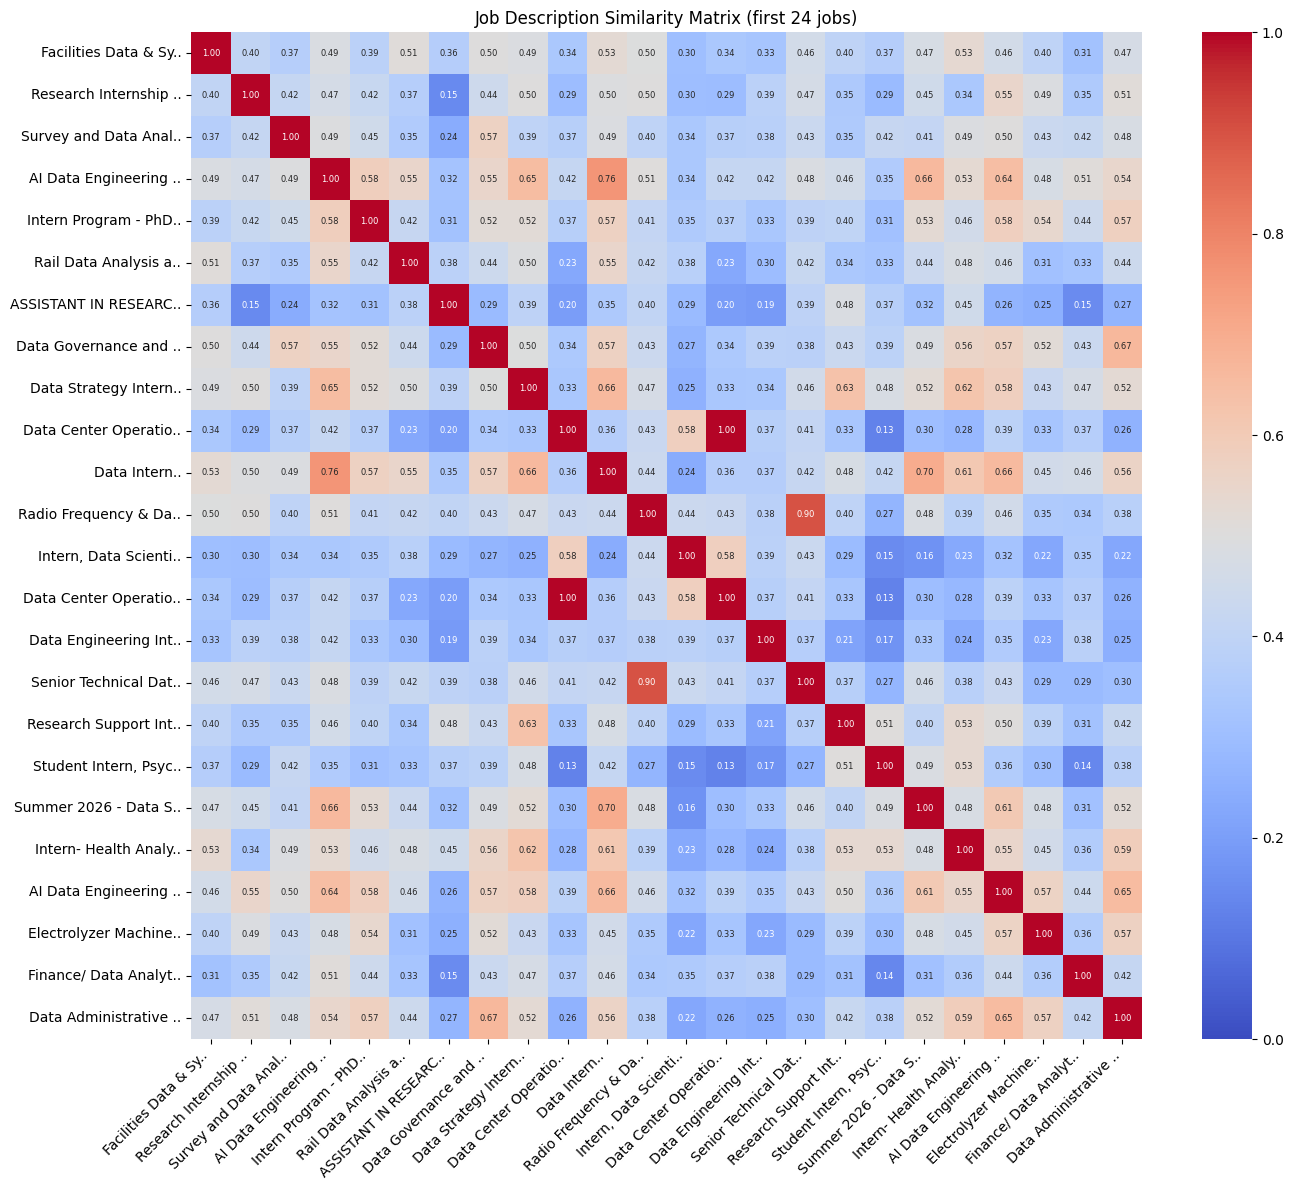

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# shortening titles for display
np.fill_diagonal(sim_matrix, 1)
labels = [df_filtered['job_title'].iloc[i][:20] + '..' for i in range(24)]

plt.figure(figsize=(14, 12))
sns.heatmap(sim_matrix,
            xticklabels=labels,
            yticklabels=labels,
            cmap='coolwarm',
            vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6})
plt.title("Job Description Similarity Matrix (first 24 jobs)")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Dimensionality Reduction
- utilizing UMAP to compress the 384 dimension embedding to a lower dimension so clustering models can work more effectively

>visualizing how UMAP reduces a 784 dimension Fashion MNIST dataset to 3 dimensions



- Uses graph layout algorithms to aggrange data in low-dimensional space.
- UMAP constructs a high dimensional graph representation of the data than optimizes a low dimensional graph to be as structually similar as possible.
- The map behind UMAP's algorithm leverages topology
- To construct a high-dimensional graph, UMAP builds a 'fuzzy simplicial complex'. Which is a representation of a weighted graph, with edge weights representing the likelihood that two points are connected.
- To determine connectedness, UMAP extends a radius outwards form each point, connecting points when those radii overlap.
- UMAP chooses a radius locally, based on the distance to each point's nth nearest neighbor.
- UMAP makes the graph 'fuzzy' by decreasing the likelihood of connection as the radius grows.
- Finally, by ensuring that each point must be connected to at least its closest neighbor, it constructs a local structure that is preserved in balance with the global structure.

> **Comparing against t-SNE:** UMAP much more clearly separates these groups of similar categories from each other. UMAP also computes much faster (7x times faster than t-SNE for the Fasion MNIST dataset)

In [ ]:
import umap
umap_model = umap.UMAP(
    n_components=5, # compress down to 5 dimensions
    n_neighbors=100,
    min_dist=0, # setting to 0 to tightly pack the data points
    metric='cosine', # again using cosine distance, as sentence transformer emebeddings are optimized for cosine similarity
    init='random',
    random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)
print(f'original embedding shape: {embeddings.shape}')
print(f'reduced embedding shape: {reduced_embeddings.shape}')

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


original embedding shape: (10603, 384)
reduced embedding shape: (10603, 5)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


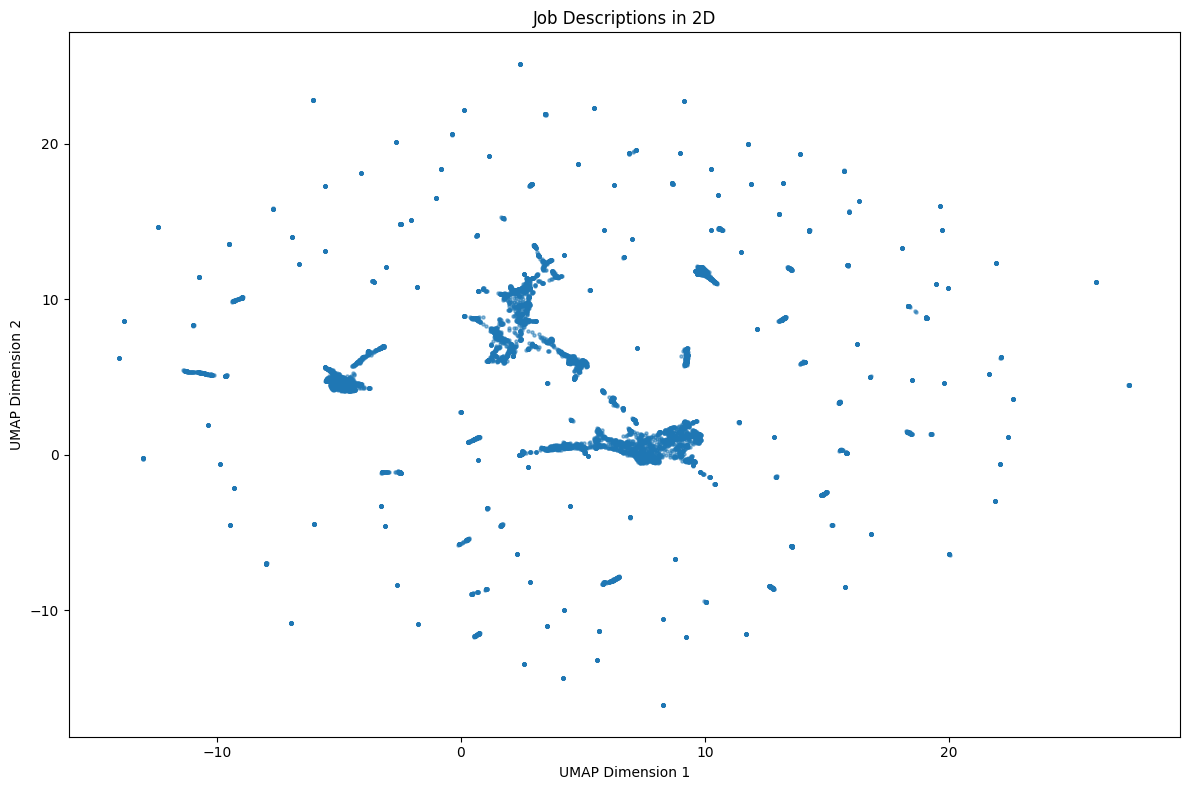

In [ ]:
# visualize the reduced data points
# fit a 2D umap on the reduced embeddings (not raw embeddings) so that
# the visualization reflects the same geometric space used for clustering
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=100,
    min_dist=0.0,      # pack tightly for cluster visibility
    metric='euclidean', # euclidean since input is already dense 5D
    init='random',
    random_state=42
)

embeddings_2d = umap_2d.fit_transform(reduced_embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.5)
plt.title("Job Descriptions in 2D")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()


# HDBSCAN Clustering
- using a density based clustering model to automatically discover clusters by finding dense regions of data points.

> How does HDBSCAN work?
- *Imagine a room full of people, where groups of people are standing close together having conversations, with empty spaces between these groups. In this scenario, each group of people can be considered a cluster. Density-based clustering would be able to identify these groups, as they are areas of high density, separated by areas of low density.*

### 1. Transform feature space using a metric called **mutual reachability distance**
$$MRD(a,b) = max(coreDistance_k(a), coreDistance_k(b), d(a, b))$$
- $d(a, b)$ is the distance between point a and b
- `coreDistance` is the distance from a point to its kth nearest neighbor
- `k` is a hyperparameter
- Transforming the space with mutual reachability distances helps to emphasize the density-based relationships between points. Allowing the algorithm to be sensitive to local desnity variations
### 2. Constructing the Minimum Spanning Tree (MST)
- Once mutual reachability distances between all pairs of points are calculated, next step is to construct a minumum spanning tree based on these distances.
- An MST is a tree that connects all points in such a way that the sum of the edge weights (mutual reachability distances) is minimized
### 3. Building the Hierarchy
- constructs a hierarchical tree from the MST in the form of a 'clusster hierarchy'.
The leaf node of the tree corresponds to a single data point, and as we traverse upwards, nodes merged based on edge weights in the MST
### 4. Condensing the Tree
- Clusters that are less stable over varying density thresholds are 'pruned'
- The result is a simplified version of the initial hierarchial tree.
- Retains only those clusters that have shown enough stability over the various density levels
### 5. Extracting the final clusters
- Every data point is labeled according to the clusters it belongs to in the condensed tree.
- The points that do not belong to any clusters are classified as 'noise'. (assigned with a label of 1)

### Limitations:
- High dimensional data
- computationally intensive against large datasets


In [ ]:
import hdbscan
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=100, # defining the minimum num of jobs needed to form a cluster
    min_samples=2,  # controls how much samples need to exist can be declared as a dense region by HDBSCAN
    metric='euclidean',
    cluster_selection_method='leaf', # finds more balanced clusters
    core_dist_n_jobs=1  # disable parallelism for full reproducibility under random_state=42 in UMAP
)

cluster_labels = cluster_model.fit_predict(reduced_embeddings)

# inspect results
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
# calculate number of unclustered jobs (umap labels noise as -1)
n_noise = (cluster_labels == -1).sum()
print(f'number of clusters found: {n_clusters}')
print(f'number unclustered jobs: {n_noise} (about {n_noise/len(cluster_labels)*100:.1f}%)')
print(f'\nCluster sizes:\n')
for label in sorted(set(cluster_labels)):
  count = (cluster_labels == label).sum()
  name = "Noise Cluster" if label == -1 else f'Cluster {label}'
  print(f'{name}: {count} jobs')


number of clusters found: 25
number unclustered jobs: 4907 (about 46.3%)

Cluster sizes:

Noise Cluster: 4907 jobs
Cluster 0: 100 jobs
Cluster 1: 233 jobs
Cluster 2: 206 jobs
Cluster 3: 119 jobs
Cluster 4: 143 jobs
Cluster 5: 105 jobs
Cluster 6: 157 jobs
Cluster 7: 130 jobs
Cluster 8: 179 jobs
Cluster 9: 214 jobs
Cluster 10: 325 jobs
Cluster 11: 178 jobs
Cluster 12: 617 jobs
Cluster 13: 294 jobs
Cluster 14: 163 jobs
Cluster 15: 130 jobs
Cluster 16: 132 jobs
Cluster 17: 371 jobs
Cluster 18: 397 jobs
Cluster 19: 208 jobs
Cluster 20: 439 jobs
Cluster 21: 119 jobs
Cluster 22: 243 jobs
Cluster 23: 295 jobs
Cluster 24: 199 jobs


### Evaluating Silouette Score

In [ ]:
from sklearn.metrics import silhouette_score

mask = cluster_labels != -1
valid_labels = cluster_labels[mask]

if len(set(valid_labels)) >= 2:
    score = silhouette_score(reduced_embeddings[mask], valid_labels)
    print(f"Silhouette Score: {score:.4f}")
else:
    print("Not enough clusters to compute silhouette score.")

Silhouette Score: 0.6046


# Hyperparameter Optimization via Grid Search
- systematically evaluating combinations of UMAP and HDBSCAN parameters to find the configuration that maximizes clustering quality
- optimizing for silhouette score while also tracking the number of clusters and noise rate to avoid degenerate solutions (e.g. 1 giant cluster or 99% noise)

- **silhouette score**: measures how well-separated clusters are (higher is better, range -1 to 1)
- **n_clusters**: number of meaningful clusters found (we want a reasonable number, not 1 or 100+)
- **noise_rate**: fraction of points labeled as noise by HDBSCAN (too high means the clustering is too strict)
- a good result balances all three — high silhouette, meaningful cluster count, and acceptable noise rate

In [ ]:
# import itertools
# from sklearn.metrics import silhouette_score

# # define the hyperparameter grid
# # these include the current values as well as neighboring configurations to explore
# param_grid = {
#     'n_components': [3, 5, 10],          # UMAP output dimensions
#     'n_neighbors':  [50, 100, 150],       # UMAP neighbor count
#     'min_cluster_size': [50, 100, 200],       # HDBSCAN min cluster size
#     'min_samples': [2, 5, 10],           # HDBSCAN min samples
# }

# results = []

# # generate all combinations
# keys = list(param_grid.keys())
# combos = list(itertools.product(*param_grid.values()))

# print(f"Total combinations to evaluate: {len(combos)}")
# print("Running grid search...\n")

# for i, combo in enumerate(combos):
#     params = dict(zip(keys, combo))

#     try:
#         # UMAP reduction
#         umap_gs = umap.UMAP(
#             n_components=params['n_components'],
#             n_neighbors=params['n_neighbors'],
#             min_dist=0.0,
#             metric='cosine',
#             init='random',
#             random_state=42
#         )
#         reduced_gs = umap_gs.fit_transform(embeddings)

#         # HDBSCAN clustering
#         hdb_gs = hdbscan.HDBSCAN(
#             min_cluster_size=params['min_cluster_size'],
#             min_samples=params['min_samples'],
#             metric='euclidean',
#             cluster_selection_method='leaf'
#         )
#         labels_gs = hdb_gs.fit_predict(reduced_gs)

#         # compute metrics
#         n_clusters = len(set(labels_gs)) - (1 if -1 in labels_gs else 0)
#         noise_rate = (labels_gs == -1).sum() / len(labels_gs)

#         # silhouette only valid with >=2 clusters and some non-noise points
#         mask_gs = labels_gs != -1
#         if n_clusters >= 2 and mask_gs.sum() > n_clusters:
#             sil = silhouette_score(reduced_gs[mask_gs], labels_gs[mask_gs])
#         else:
#             sil = -1.0

#         results.append({
#             **params,
#             'n_clusters':  n_clusters,
#             'noise_rate':  round(noise_rate, 3),
#             'silhouette':  round(sil, 4),
#         })

#         if (i + 1) % 10 == 0:
#             print(f"  [{i+1}/{len(combos)}] n_components={params['n_components']}, "
#                   f"n_neighbors={params['n_neighbors']}, "
#                   f"min_cluster_size={params['min_cluster_size']}, "
#                   f"min_samples={params['min_samples']} "
#                   f"→ clusters={n_clusters}, noise={noise_rate:.1%}, sil={sil:.4f}")

#     except Exception as e:
#         print(f"  [{i+1}/{len(combos)}] Failed with params {params}: {e}")
#         results.append({**params, 'n_clusters': 0, 'noise_rate': 1.0, 'silhouette': -1.0})

# results_df = pd.DataFrame(results)
# print("\nGrid search complete.")
# print(f"Total configurations evaluated: {len(results_df)}")


- inspect the top results, filtering out degenerate cases where clustering collapsed to 1 cluster or noise rate is unreasonably high

In [ ]:
# # filter out degenerate results
# # require: at least 5 clusters, at most 70% noise, silhouette > 0
# valid_results = results_df[
#     (results_df['n_clusters'] >= 5) &
#     (results_df['noise_rate'] <= 0.70) &
#     (results_df['silhouette'] > 0)
# ].copy()

# print(f"Valid configurations: {len(valid_results)} / {len(results_df)}")
# print("\nTop 10 configurations by silhouette score:\n")
# print(valid_results.sort_values('silhouette', ascending=False).head(10).to_string(index=False))


- visualize the grid search results as a heatmap to understand which parameter combinations consistently perform well

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # pivot to show silhouette score across min_cluster_size vs n_neighbors
# # averaged over other dimensions
# pivot = results_df.groupby(['n_neighbors', 'min_cluster_size'])['silhouette'].mean().reset_index()
# pivot_table = pivot.pivot(index='n_neighbors', columns='min_cluster_size', values='silhouette')

# plt.figure(figsize=(8, 5))
# sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
# plt.title("Mean Silhouette Score\nn_neighbors vs min_cluster_size (averaged over other params)")
# plt.xlabel("min_cluster_size")
# plt.ylabel("n_neighbors")
# plt.tight_layout()
# plt.show()

# # also plot noise rate heatmap
# pivot_noise = results_df.groupby(['n_neighbors', 'min_cluster_size'])['noise_rate'].mean().reset_index()
# pivot_noise_table = pivot_noise.pivot(index='n_neighbors', columns='min_cluster_size', values='noise_rate')

# plt.figure(figsize=(8, 5))
# sns.heatmap(pivot_noise_table, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
# plt.title("Mean Noise Rate\nn_neighbors vs min_cluster_size (averaged over other params)")
# plt.xlabel("min_cluster_size")
# plt.ylabel("n_neighbors")
# plt.tight_layout()
# plt.show()


- extract the single best configuration and re-run the final pipeline with those optimal parameters

In [ ]:
"""
  n_components: 3
  n_neighbors: 100
  min_cluster_size: 50
  min_samples: 10
  n_clusters: 46
  noise_rate: 47.0%
  silhouette: 0.7028
"""

best_n_components = 10
best_n_neighbors = 50
best_min_cluster_size = 50
best_min_samples = 10

In [ ]:
# select best config: highest silhouette among valid results

# # TEMPORARILY COMMENTED OUT TO NOT RERUN THE GRIDSEARCH
# best_row = valid_results.sort_values('silhouette', ascending=False).iloc[0]

# best_n_components = int(best_row['n_components'])
# best_n_neighbors = int(best_row['n_neighbors'])
# best_min_cluster_size = int(best_row['min_cluster_size'])
# best_min_samples = int(best_row['min_samples'])

# print("Best configuration found:")
# print(f"n_components: {best_n_components}")
# print(f"n_neighbors: {best_n_neighbors}")
# print(f"min_cluster_size: {best_min_cluster_size}")
# print(f"min_samples: {best_min_samples}")
# print(f"n_clusters: {int(best_row['n_clusters'])}")
# print(f"noise_rate: {best_row['noise_rate']:.1%}")
# print(f"silhouette: {best_row['silhouette']:.4f}")

# re-run UMAP with best params
print("\nRe-running UMAP with best parameters...")
umap_model = umap.UMAP(
    n_components=best_n_components,
    n_neighbors=best_n_neighbors,
    min_dist=0.0,
    metric='cosine',
    init='random',
    random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)
print(f"Reduced embedding shape: {reduced_embeddings.shape}")

# re-run HDBSCAN with best params
# core_dist_n_jobs=1 disables parallelism for full reproducibility
print("Re-running HDBSCAN with best parameters")
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=best_min_cluster_size,
    min_samples=best_min_samples,
    metric='euclidean',
    cluster_selection_method='leaf',
    core_dist_n_jobs=1
)
cluster_labels = cluster_model.fit_predict(reduced_embeddings)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"\nNumber of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(cluster_labels):.1%})")
print("\nCluster sizes:")
for label in sorted(set(cluster_labels)):
    count = (cluster_labels == label).sum()
    name  = "Noise" if label == -1 else f"Cluster {label}"
    print(f"  {name}: {count} jobs")

# re-run 2D UMAP for visualization
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=best_n_neighbors,
    min_dist=0.0,
    metric='euclidean',
    init='random',
    random_state=42
)
embeddings_2d = umap_2d.fit_transform(reduced_embeddings)

# silhouette score on best config
mask_best = cluster_labels != -1
if len(set(cluster_labels[mask_best])) >= 2:
    best_sil = silhouette_score(reduced_embeddings[mask_best], cluster_labels[mask_best])
    print(f"\nSilhouette Score (best config): {best_sil:.4f}")



Re-running UMAP with best parameters...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (10603, 10)
Re-running HDBSCAN with best parameters

Number of clusters: 45
Noise points: 5395 (50.9%)

Cluster sizes:
  Noise: 5395 jobs
  Cluster 0: 67 jobs
  Cluster 1: 100 jobs
  Cluster 2: 129 jobs
  Cluster 3: 143 jobs
  Cluster 4: 114 jobs
  Cluster 5: 92 jobs
  Cluster 6: 99 jobs
  Cluster 7: 50 jobs
  Cluster 8: 66 jobs
  Cluster 9: 103 jobs
  Cluster 10: 101 jobs
  Cluster 11: 100 jobs
  Cluster 12: 101 jobs
  Cluster 13: 63 jobs
  Cluster 14: 120 jobs
  Cluster 15: 73 jobs
  Cluster 16: 69 jobs
  Cluster 17: 213 jobs
  Cluster 18: 99 jobs
  Cluster 19: 54 jobs
  Cluster 20: 336 jobs
  Cluster 21: 54 jobs
  Cluster 22: 65 jobs
  Cluster 23: 202 jobs
  Cluster 24: 178 jobs
  Cluster 25: 125 jobs
  Cluster 26: 53 jobs
  Cluster 27: 223 jobs
  Cluster 28: 87 jobs
  Cluster 29: 258 jobs
  Cluster 30: 57 jobs
  Cluster 31: 59 jobs
  Cluster 32: 51 jobs
  Cluster 33: 68 jobs
  Cluster 34: 69 jobs
  Cluster 35: 92 jobs
  Cluster 36: 100 jobs
  Cluster 37: 10

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Silhouette Score (best config): 0.7028


# Extracting keywords from each cluster with TF-IDF
- term frequency: how often a word appears in a document
- inverse document frequency: how rare that word is across all documents

TF-IDF = Term Frequency × Inverse Document Frequency
Term Frequency (TF):

- How often a word appears in THIS document
- Formula: count(word in doc) / total words in doc


Inverse Document Frequency (IDF):

- How rare the word is across ALL documents
- Formula: log(total documents / documents containing word)

Rare words get high IDF; common words get low IDF

High score = word appears frequently in this doc BUT rarely in others → distinctive/important
Low score = word is either rare in this doc OR appears everywhere → not distinctive

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# define a class based tf_idf function that calculate tf-idf scores for each cluster
# this suits our case as each cluster is a document, rather than each job description
def c_tf_idf(documents, m, ngram_range=(1, 2)):
    # create vocabulary of all words/phrases
    # 1 word and 2 word phrases
    count = CountVectorizer(ngram_range=ngram_range, stop_words="english").fit(documents)

    # define a word count matrix
    # where rows=clusters, columns=words, values=word counts
    t = count.transform(documents).toarray()

    # total words in each cluster
    total_words = t.sum(axis=1)

    # term frequency calculation
    # the number shows what % of cluster's words is a word
    tf = np.divide(t.T, total_words)

    # calculate how many times each word appears across all clusters
    sum_t = t.sum(axis=0)

    # inverse document frequency caluclation
    # finds whether a word is rare or common across clusters
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)

    # final tf-idf score
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

# Prepare documents per cluster
docs_per_cluster = []
for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:  # skip unclustered data
        continue
    cluster_docs = df_filtered[cluster_labels == cluster_id]['cleaned_description'].tolist()
    docs_per_cluster.append(" ".join(cluster_docs))

# Calculate tf-idf score
tf_idf, count = c_tf_idf(docs_per_cluster, m=len(docs_per_cluster))

# Extract top 10 keywords per cluster
def extract_top_n_words_per_topic(tf_idf, count, n=10):
    words = count.get_feature_names_out()
    labels = list(range(len(docs_per_cluster)))
    tf_idf_transposed = tf_idf.T
    indices = tf_idf_transposed.argsort()[:, -n:]
    top_n_words = {label: [(words[j], tf_idf_transposed[i][j]) for j in indices[i]][::-1] for i, label in enumerate(labels)}
    return top_n_words

top_n_words = extract_top_n_words_per_topic(tf_idf, count, n=10)

print("Top occurring keywords per cluster:\n")
for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        continue
    cluster_size = (cluster_labels == cluster_id).sum()
    actual_cluster_idx = list(sorted(set(cluster_labels)))[cluster_id + 1]  # adjust for -1 noise
    print(f"Cluster {cluster_id} ({cluster_size} jobs):")
    words = [word for word, score in top_n_words[cluster_id]]
    print(f"  {', '.join(words)}\n")

Top occurring keywords per cluster:

Cluster 0 (67 jobs):
  internship smsc, prior lake, premier casino, dynamic gaming, lake casino, lake mn, minnesota premier, communication smsc, internship mystic, lake little

Cluster 1 (100 jobs):
  gamble 12, polymer science, polymer, scale materials, science polymer, graduation bs, development device, biochemistry microbiology, kay, freshmen juniors

Cluster 2 (129 jobs):
  flink snowflake, credit systems, ads data, tensorflow tiktok, etl schema, field hadoop, tiktok ads, development computer, databricks bigquery, experience turn

Cluster 3 (143 jobs):
  minimum month, languages statistical, econometrics mathematics, methods experimentation, definition root, community detection, inference causal, forecasting causal, analyses business, seeking project

Cluster 4 (114 jobs):
  bachelor analytics, sql alteryx, security pwc, finance technology, pwc cloud, manipulation algorithm, deals technology, year python, development pwc, client teams

Cluster 5

# Insights extraction via Language Models
- using a LLM to identify each clusters' labels

In [ ]:
from google.colab import userdata
from openai import OpenAI
import json
import re

# 1. Initialize the OpenAI Client
openai_api = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=openai_api)
df_filtered['cluster'] = cluster_labels

# 2. Data Preparation: Aggregate all cluster data into a single string for the prompt
all_clusters_input = ""
unique_ids = sorted([cid for cid in set(df_filtered['cluster']) if cid != -1])

cluster_keywords = {}
for cluster_id in unique_ids:
    cluster_size = (df_filtered['cluster'] == cluster_id).sum()
    # Ensure we use the top_n_words dictionary from your previous step
    words = [word for word, score in top_n_words[cluster_id]]
    cluster_keywords[cluster_id] = {
        'size': cluster_size,
        'keywords': words[:50]
    }
    all_clusters_input += f'\nCluster {cluster_id} ({cluster_size} jobs):\n'
    all_clusters_input += f'Keywords: {", ".join(words[:50])}\n'

# 3. Refined Batch Prompt with strict unique domain-specific rules
prompt = f"""
You are an expert technical recruiter and labor market economist.
I will give you a list of the top 50 TF-IDF keywords extracted from several clusters of job descriptions.
Your singular task is to identify the real-world, industry-standard job title that represents each cluster.

STRICT RULES
1. You must output exactly ONE unique job title per Cluster ID.
2. EVERY LABEL MUST BE UNIQUE. No two clusters can have the same title.
3. IDENTIFY THE SUBDOMAIN: If a cluster appears to be a general role, you MUST identify its specific industry or functional niche (e.g., "Marketing Analytics Specialist", "Supply Chain Data Analyst").
4. You must NOT output skills, tools, software, or algorithms.
5. You must NOT output compound academic phrases.
6. Output ONLY a valid JSON object where keys are the Cluster IDs and values are the titles.

GOOD EXAMPLES
Data Engineer
Machine Learning Engineer
Quantitative Analyst
Healthcare Data Scientist
Marketing Data Analyst

BAD EXAMPLES (NEVER DO THIS)
Machine Learning - Neural Networks
Python Data Processing
Deep Learning
Analytics and SQL
SQL Analyst
Python Analyst

Here are the clusters:
{all_clusters_input}

Return ONLY the JSON object, no other text.
"""

# 4. Call OpenAI in Batch Mode
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a labor market analyst who creates clear, unique, and domain-specific labels that truly exist in the job market."},
        {"role": "user", "content": prompt}
    ],
    temperature=0.2
)

response_text = response.choices[0].message.content
print("\nGPT Output:")
print(response_text)

# 5. Extract JSON and Map back to the dataframe
try:
    # Strip markdown code blocks (```json ... ```)
    clean_json = re.sub(r'^```json\s*|```$', '', response_text.strip(), flags=re.MULTILINE)
    cluster_names_raw = json.loads(clean_json)

    # Convert keys to integers and values to strings to match the cluster column
    cluster_mapping = {int(k): str(v) for k, v in cluster_names_raw.items()}

    print("\nSuccessfully Generated Unique Domain Labels:")
    for cid, name in sorted(cluster_mapping.items()):
        print(f"Cluster {cid}: {name}")

    # Map the human-readable labels to your dataframe
    df_filtered['job_function_label'] = df_filtered['cluster'].map(cluster_mapping).fillna("Unclustered/Noise")

except Exception as e:
    print(f"\nError processing response: {e}")
    print("Raw Response was:")
    print(response_text)


GPT Output:
```json
{
  "0": "Casino Operations Intern",
  "1": "Polymer Science Intern",
  "2": "Data Engineering Intern",
  "3": "Quantitative Research Intern",
  "4": "Financial Technology Analyst",
  "5": "AI Visualization Engineer",
  "6": "Business Intelligence Analyst",
  "7": "Supply Chain Analyst",
  "8": "3D Modeling Analyst",
  "9": "Machine Learning Intern",
  "10": "Manufacturing Data Analyst",
  "11": "Business Analyst Intern",
  "12": "Data Migration Specialist",
  "13": "Political Research Analyst",
  "14": "Entertainment Data Analyst",
  "15": "Aviation Management Intern",
  "16": "Quantitative Analyst",
  "17": "Healthcare Data Analyst",
  "18": "Supply Chain Data Analyst",
  "19": "Operations Analyst",
  "20": "Materials Scientist",
  "21": "Urban Resilience Intern",
  "22": "Optimization Analyst",
  "23": "Energy Analyst",
  "24": "Data Verification Specialist",
  "25": "Business Analytics Intern",
  "26": "Data Integration Intern",
  "27": "Mortgage Data Analyst",

# Visualization of LLM parsed clustered names

- visualize UMAP cluster distribution
- visualize bar chart

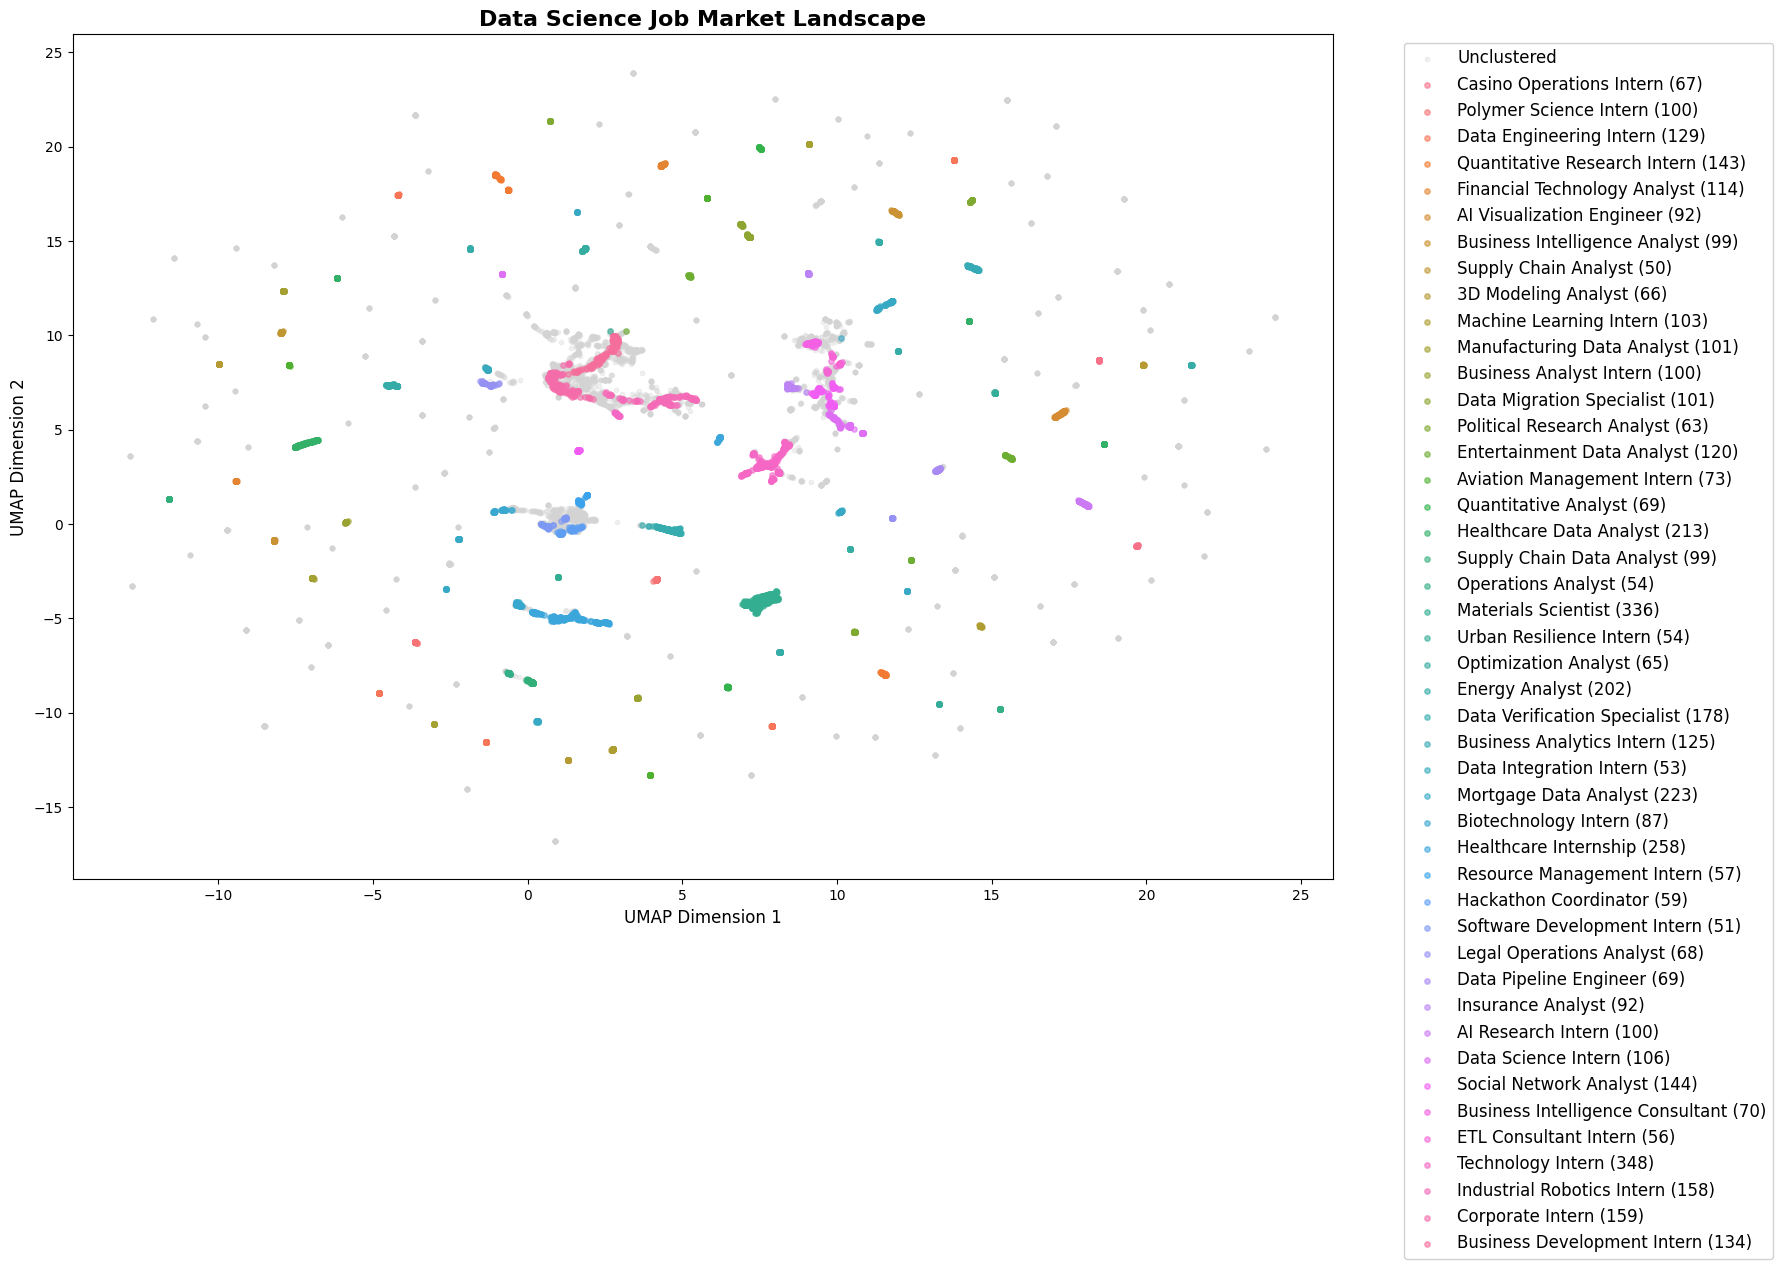


Distribution of Cluster size
cluster_name
Unclustered                         5395
Technology Intern                    348
Materials Scientist                  336
Healthcare Internship                258
Mortgage Data Analyst                223
Healthcare Data Analyst              213
Energy Analyst                       202
Data Verification Specialist         178
Corporate Intern                     159
Industrial Robotics Intern           158
Social Network Analyst               144
Quantitative Research Intern         143
Business Development Intern          134
Data Engineering Intern              129
Business Analytics Intern            125
Entertainment Data Analyst           120
Financial Technology Analyst         114
Data Science Intern                  106
Machine Learning Intern              103
Manufacturing Data Analyst           101
Data Migration Specialist            101
Business Analyst Intern              100
Polymer Science Intern               100
AI Research In

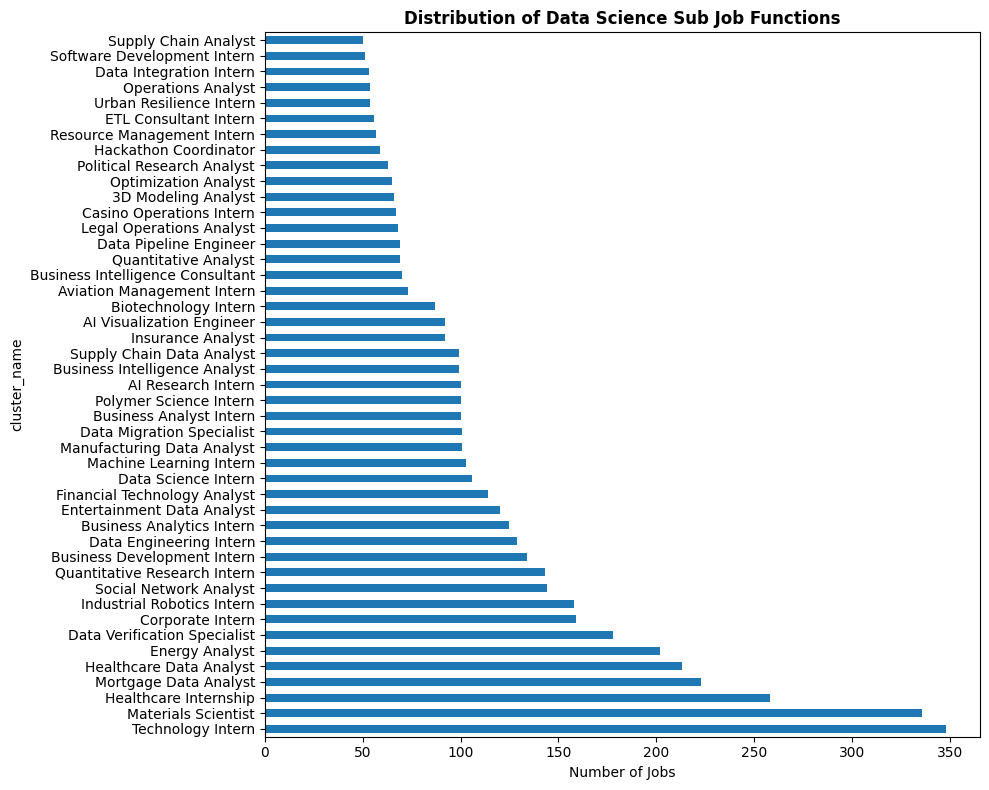

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# MINIMAL FIX: Alias the dictionary name if it was called cluster_mapping in the previous cell
if 'cluster_mapping' in locals() and 'cluster_names' not in locals():
    cluster_names = cluster_mapping

# 1. ASSIGNMENT: Ensure the labels and names are synced to the dataframe
df_filtered['cluster'] = cluster_labels

# Use the mapping dictionary from your GPT cell
df_filtered['cluster_name'] = df_filtered['cluster'].map(cluster_names).fillna('Unclustered')

# create a colored 2D visualization
plt.figure(figsize=(18, 12))

# plot noisy data points as grey backgrounds
noise_mask = cluster_labels == -1
if noise_mask.any():
    plt.scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1],
                s=10, alpha=0.3, c='lightgray', label='Unclustered')

# plot each cluster with a different color
n_clusters = len(cluster_names)
colors = sns.color_palette("husl", n_clusters)

for idx, (cluster_id, name) in enumerate(sorted(cluster_names.items())):
    mask = cluster_labels == cluster_id
    if mask.any(): # Only plot if there are points in the cluster
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    s=15, alpha=0.6, c=[colors[idx]], label=f"{name} ({mask.sum()})")

plt.title("Data Science Job Market Landscape", fontsize=16, fontweight='bold')
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, framealpha=0.9)
plt.tight_layout()
plt.show()

# show cluster size distribution
print("\nDistribution of Cluster size")
cluster_counts = df_filtered['cluster_name'].value_counts()
print(cluster_counts)

# visualize cluster sizes as a bar chart
plt.figure(figsize=(10, 8))
cluster_counts[cluster_counts.index != 'Unclustered'].plot(kind='barh')
plt.xlabel("Number of Jobs")
plt.title("Distribution of Data Science Sub Job Functions", weight='bold')
plt.tight_layout()
plt.show()

- Visualize and understand the clusters better with plotly

In [ ]:
import plotly.express as px

plot_df = pd.DataFrame({
    'UMAP1': embeddings_2d[:, 0],
    'UMAP2': embeddings_2d[:, 1],
    'Cluster': df_filtered['cluster_name'].values,
    'Job Title': df_filtered['job_title'].values,
    'Cluster_ID': cluster_labels
})

fig = px.scatter(
    plot_df[plot_df['Cluster'] != 'Unclustered'],
    x='UMAP1',
    y='UMAP2',
    color='Cluster',
    hover_data=['Job Title'],
    title='Data Science Job Market Landscape (Interactive)',
    width=1200,
    height=800,
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.01))
fig.show()

In [ ]:
# save plotly graph
fig.write_html('data_science_job_market_landscape.html')


# Temporal Cluster Stability Analysis via Maximum Mean Discrepancy (MMD)
- MMD measures distributional shift in embedding space between time windows
- for each labeled cluster, we compute pairwise MMD scores across consecutive monthly snapshots of job postings
- high MMD between two consecutive months signals that the cluster's composition changed significantly during that period

## Step 1: Attach month bins to the clustered dataframe

In [ ]:
import pandas as pd
import numpy as np

# ensure time column is datetime and attach to the clustered df
df_filtered['time_posted_parsed'] = pd.to_datetime(df_filtered['time_posted_parsed'], errors='coerce')

# create a year-month period column for grouping
df_filtered['month_bin'] = df_filtered['time_posted_parsed'].dt.to_period('M')

# attach cluster labels and embeddings
df_filtered['cluster'] = cluster_labels
df_filtered['cluster_name'] = df_filtered['cluster'].map(cluster_names).fillna('Unclustered')

# attach embedding index for retrieval (embeddings array is aligned with df_filtered index after dedup+reset)
df_filtered['emb_idx'] = np.arange(len(df_filtered))

# show the time distribution of postings per month
print("Postings per month:")
print(df_filtered.groupby('month_bin').size().to_string())
print(f"\nMonths available: {sorted(df_filtered['month_bin'].dropna().unique())}")


Postings per month:
month_bin
2025-12     609
2026-01     685
2026-02    1287
2026-03     850
2026-04    1044
2026-05      47
Freq: M

Months available: [Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]


/tmp/ipykernel_14164/1539905844.py:8: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



## Step 2: Define the MMD function

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(X, Y, gamma=None):
    """
    Maximum Mean Discrepancy between two sets of embedding vectors X and Y.
    Uses an RBF (Gaussian) kernel. gamma=None auto-sets to 1 / (2 * median_pairwise_distance^2).
    Returns a scalar >= 0. Zero means identical distributions.
    """
    if len(X) < 2 or len(Y) < 2:
        return np.nan

    if gamma is None:
        # median heuristic: set gamma based on pairwise distances in the combined sample
        combined = np.vstack([X, Y])
        from sklearn.metrics.pairwise import euclidean_distances
        dists = euclidean_distances(combined)
        median_dist = np.median(dists[dists > 0])
        gamma = 1.0 / (2.0 * median_dist ** 2) if median_dist > 0 else 0.01

    XX = rbf_kernel(X, X, gamma=gamma).mean()
    YY = rbf_kernel(Y, Y, gamma=gamma).mean()
    XY = rbf_kernel(X, Y, gamma=gamma).mean()
    return float(XX + YY - 2 * XY)

print("MMD function defined.")
print("Quick sanity check:")
rng = np.random.RandomState(0)
a = rng.randn(50, 10)
b = rng.randn(50, 10)
c = a + 5  # shifted distribution
print(f"  MMD(a, a) = {compute_mmd(a, a):.6f}  (expect ~0)")
print(f"  MMD(a, b) = {compute_mmd(a, b):.6f}  (expect small, same distribution)")
print(f"  MMD(a, c) = {compute_mmd(a, c):.6f}  (expect large, shifted distribution)")


MMD function defined.
Quick sanity check:
  MMD(a, a) = 0.000000  (expect ~0)
  MMD(a, b) = 0.009025  (expect small, same distribution)
  MMD(a, c) = 0.973378  (expect large, shifted distribution)


## Step 3: Compute MMD across consecutive months for each cluster

In [ ]:
# get ordered list of months
months = sorted(df_filtered['month_bin'].dropna().unique())
print(f"Computing MMD across {len(months)} months: {months}")
print(f"Consecutive month pairs: {len(months) - 1}\n")

# only analyze named clusters (exclude noise)
named_clusters = {cid: name for cid, name in cluster_names.items()}

mmd_records = []

for cluster_id, cluster_name in sorted(named_clusters.items()):
    cluster_mask = df_filtered['cluster'] == cluster_id
    cluster_df = df_filtered[cluster_mask].dropna(subset=['month_bin'])

    # get embedding vectors for this cluster per month
    month_embeddings = {}
    for month in months:
        month_mask = cluster_df['month_bin'] == month
        idxs = cluster_df[month_mask]['emb_idx'].values
        if len(idxs) >= 10:  # minimum 5 postings to compute a meaningful MMD
            month_embeddings[month] = embeddings[idxs]

    available_months = sorted(month_embeddings.keys())

    if len(available_months) < 2:
        print(f"Cluster {cluster_id} ({cluster_name}): insufficient monthly data, skipping.")
        continue

    # compute pairwise MMD for consecutive month pairs
    for i in range(len(available_months) - 1):
        m1, m2 = available_months[i], available_months[i + 1]
        X = month_embeddings[m1]
        Y = month_embeddings[m2]
        mmd_val = compute_mmd(X, Y)
        mmd_records.append({
            'cluster_id':   cluster_id,
            'cluster_name': cluster_name,
            'month_from':   str(m1),
            'month_to':     str(m2),
            'transition':   f"{m1} to {m2}",
            'n_from':       len(X),
            'n_to':         len(Y),
            'mmd':          mmd_val
        })

mmd_df = pd.DataFrame(mmd_records)
print(f"MMD computed for {mmd_df['cluster_id'].nunique()} clusters across {mmd_df['transition'].nunique()} month transitions.")
print("\nSample results:")
print(mmd_df.head(10).to_string(index=False))


Computing MMD across 6 months: [Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]
Consecutive month pairs: 5

Cluster 0 (Casino Operations Intern): insufficient monthly data, skipping.
Cluster 1 (Polymer Science Intern): insufficient monthly data, skipping.
Cluster 2 (Data Engineering Intern): insufficient monthly data, skipping.
Cluster 3 (Quantitative Research Intern): insufficient monthly data, skipping.
Cluster 4 (Financial Technology Analyst): insufficient monthly data, skipping.
Cluster 5 (AI Visualization Engineer): insufficient monthly data, skipping.
Cluster 6 (Business Intelligence Analyst): insufficient monthly data, skipping.
Cluster 7 (Supply Chain Analyst): insufficient monthly data, skipping.
Cluster 8 (3D Modeling Analyst): insufficient monthly data, skipping.
Cluster 9 (Machine Learning Intern): insufficient monthly data, skipping.
Cluster 10 (Manufacturing Data Analyst): insu

## Step 4: Identify the most and least stable clusters

In [ ]:
# average MMD per cluster across all month transitions
# higher mean MMD = cluster is less stable / more volatile over time
cluster_stability = (
    mmd_df.groupby(['cluster_id', 'cluster_name'])['mmd']
    .agg(mean_mmd='mean', max_mmd='max', n_transitions='count')
    .reset_index()
    .sort_values('mean_mmd', ascending=False)
)

print("Cluster stability ranking (higher mean MMD = more distributional shift over time):")
print(cluster_stability.to_string(index=False))

print("\n--- Most volatile clusters (top 5) ---")
print(cluster_stability.head(5)[['cluster_name', 'mean_mmd', 'max_mmd']].to_string(index=False))

print("\n--- Most stable clusters (bottom 5) ---")
print(cluster_stability.tail(5)[['cluster_name', 'mean_mmd', 'max_mmd']].to_string(index=False))


Cluster stability ranking (higher mean MMD = more distributional shift over time):
 cluster_id                 cluster_name  mean_mmd  max_mmd  n_transitions
         13   Political Research Analyst  0.363734 0.363734              1
         14   Entertainment Data Analyst  0.149971 0.149971              1
         28         Biotechnology Intern  0.129835 0.233938              3
         35            Insurance Analyst  0.121429 0.121429              1
         11      Business Analyst Intern  0.103984 0.187025              3
         30   Resource Management Intern  0.088126 0.101007              2
         31        Hackathon Coordinator  0.083809 0.083809              1
         23               Energy Analyst  0.064303 0.064303              1
         32  Software Development Intern  0.059857 0.059857              1
         42   Industrial Robotics Intern  0.042561 0.079018              4
         44  Business Development Intern  0.040576 0.053896              4
         29      

## Step 5: Visualize MMD over time per cluster

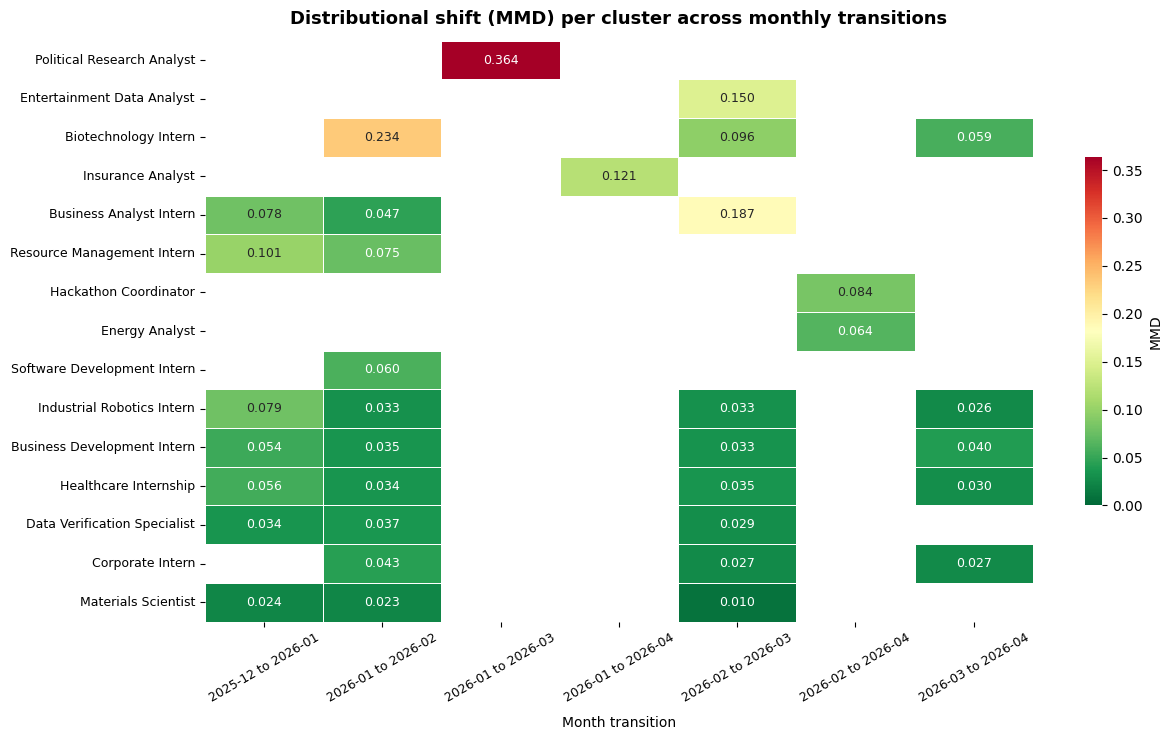

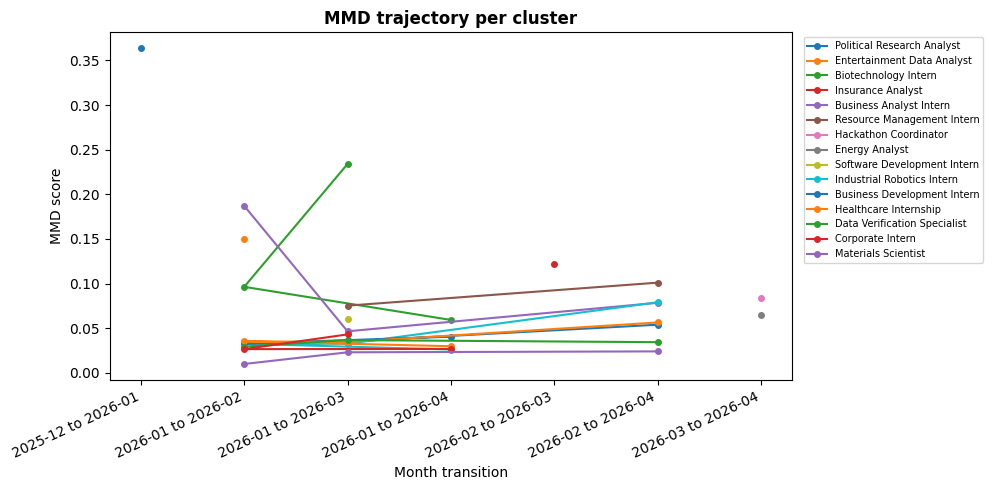

/tmp/ipykernel_14164/2220858624.py:94: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




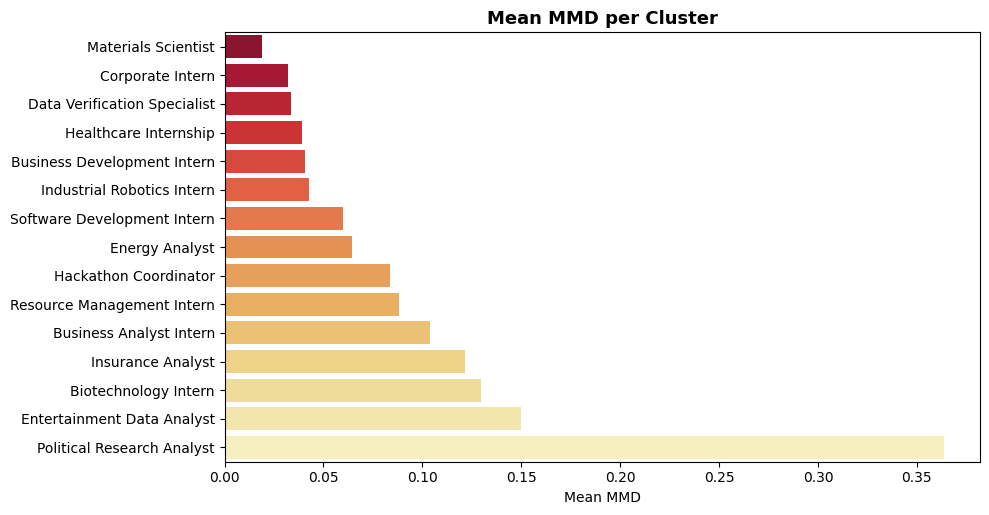

Clusters eligible for pairwise MMD heatmap: 15
Pairwise MMD computed for 15 clusters.
Plotting 15 clusters in a 5 x 3 grid


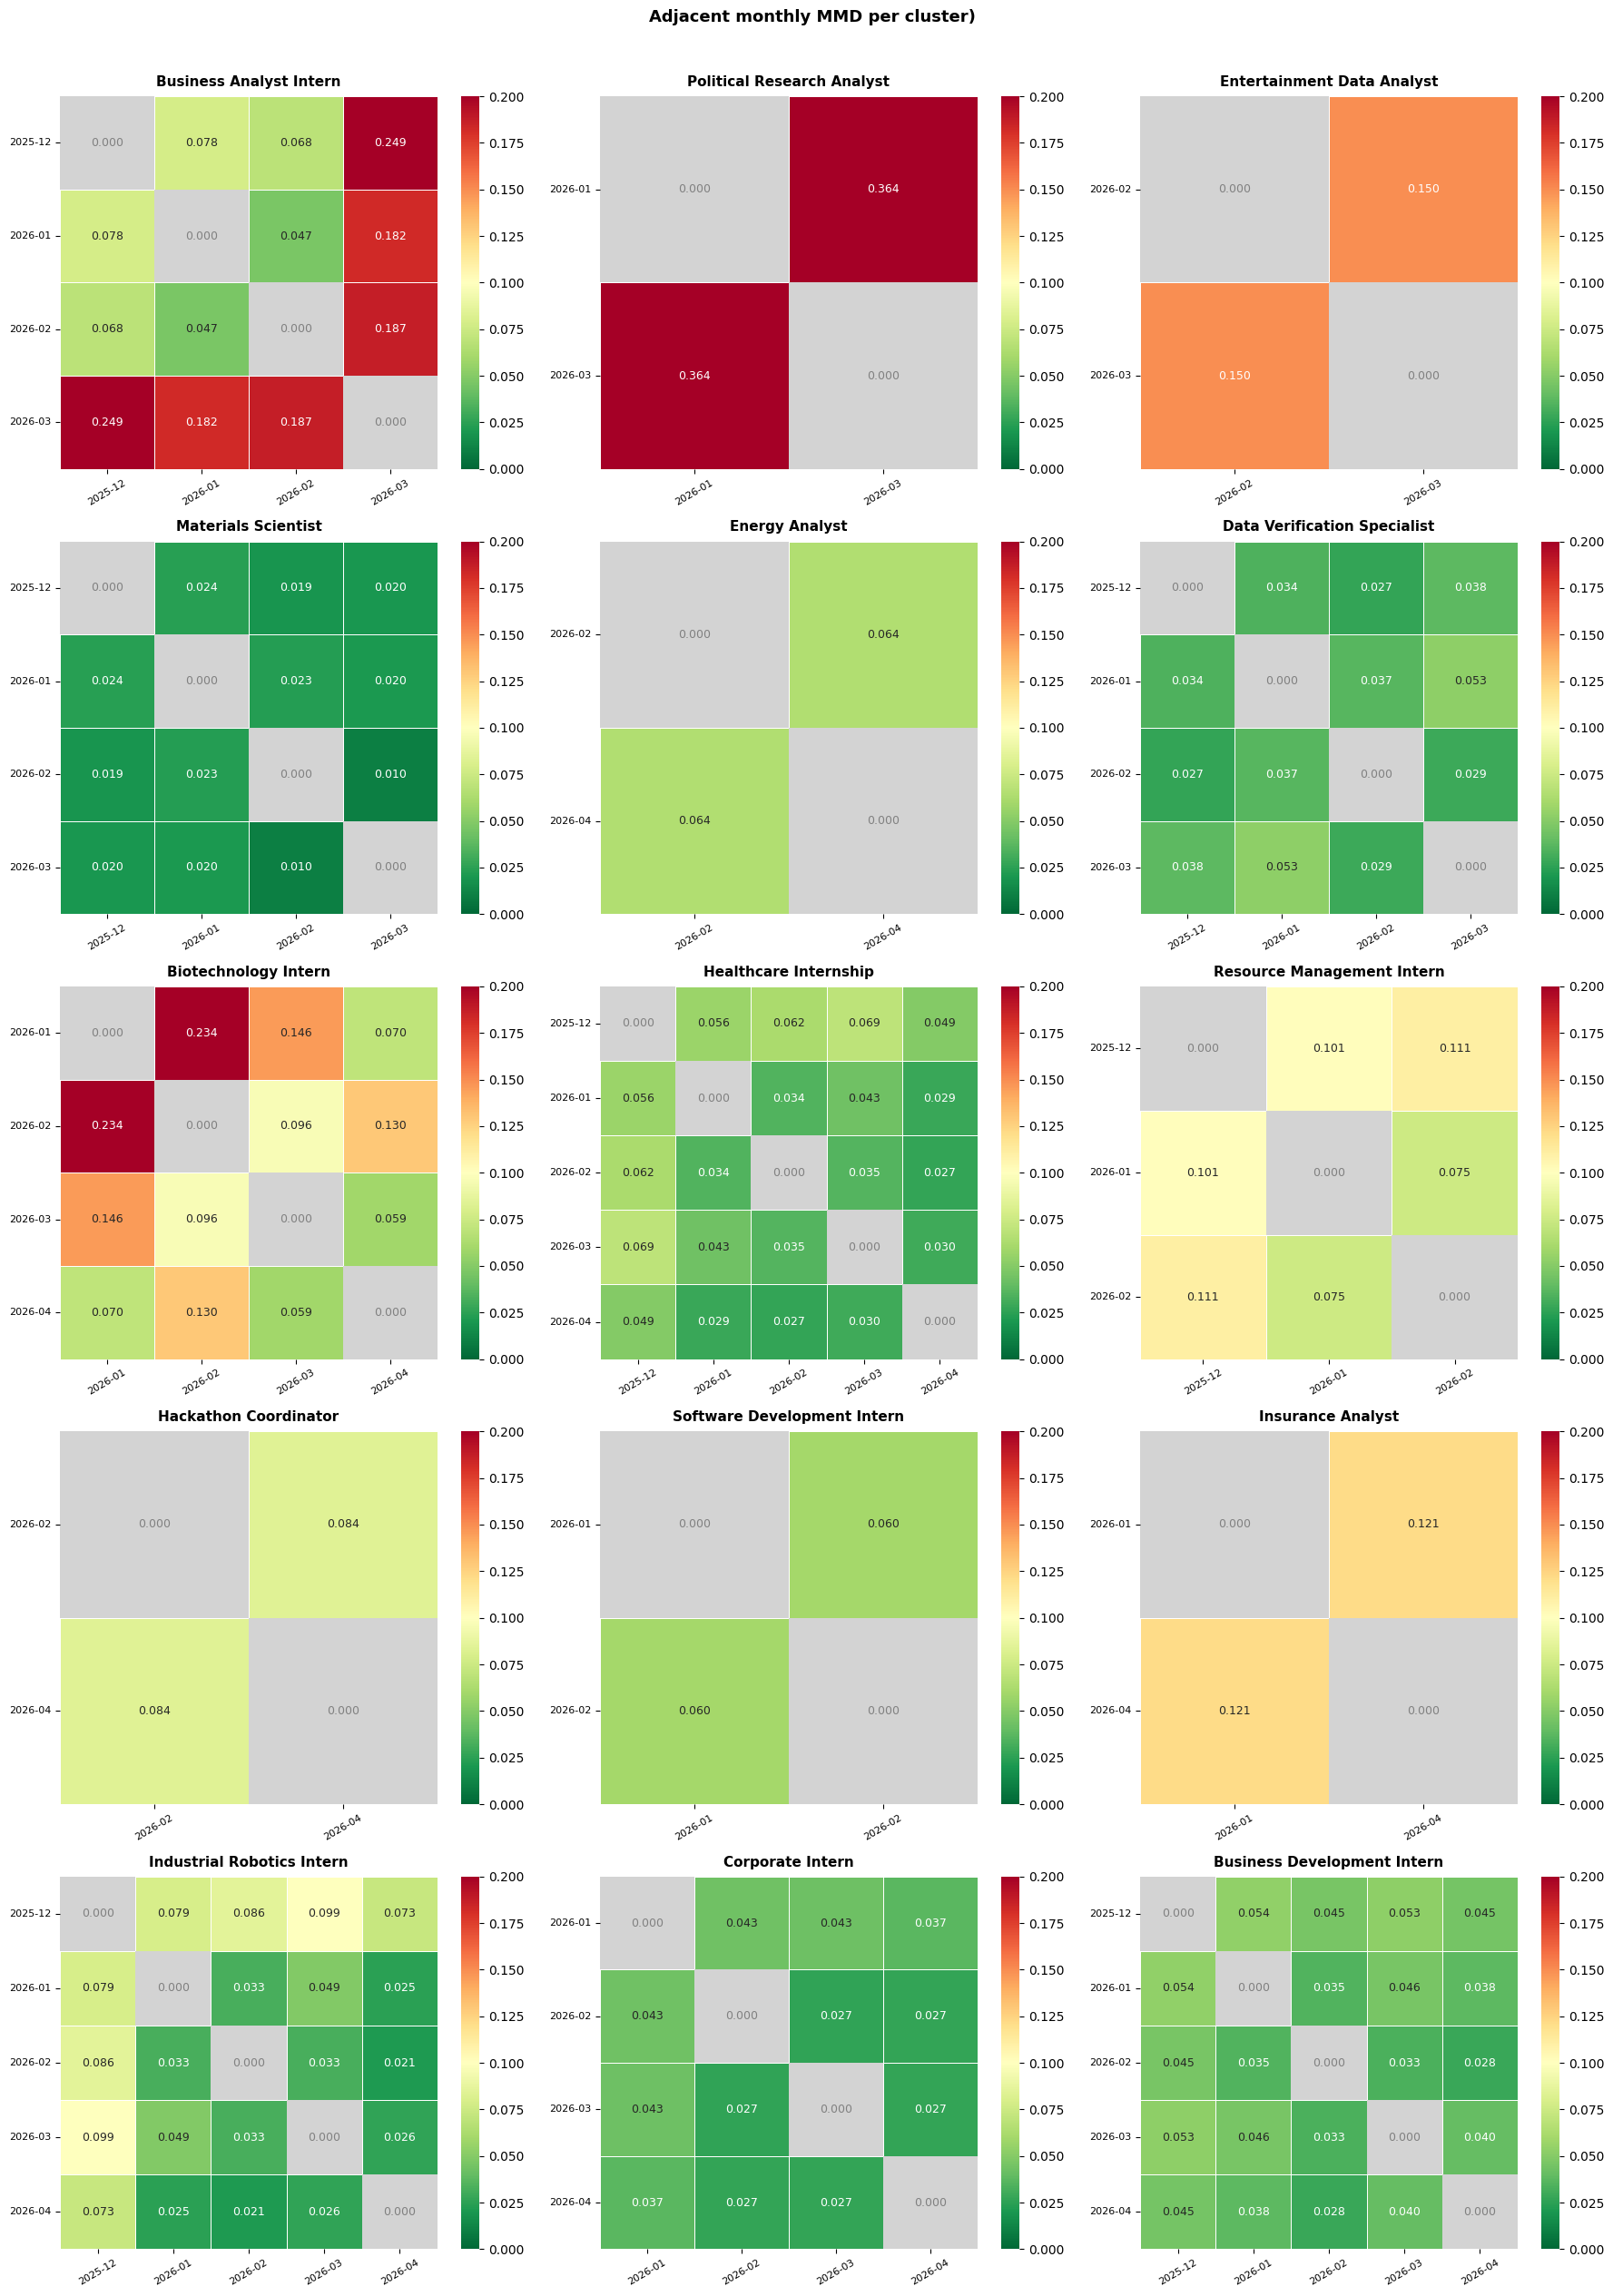

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt

# pivot to clusters x month-transitions
pivot_mmd = mmd_df.pivot_table(
    index='cluster_name',
    columns='transition',
    values='mmd',
    aggfunc='mean'
)

# sort columns chronologically
transition_order = (
    mmd_df[['month_from', 'transition']]
    .drop_duplicates()
    .sort_values('month_from')
    ['transition'].tolist()
)
pivot_mmd = pivot_mmd.reindex(columns=transition_order)

# sort rows by mean MMD descending so most volatile clusters are at top
pivot_mmd = pivot_mmd.loc[
    pivot_mmd.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(
    max(8, len(pivot_mmd.columns) * 1.8),
    max(6, len(pivot_mmd) * 0.5)
))

sns.heatmap(
    pivot_mmd,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',      # red = high shift, green = stable
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'MMD', 'shrink': 0.6},
    annot_kws={'size': 9},
    vmin=0,
    vmax=pivot_mmd.max().max()
)

ax.set_title(
    "Distributional shift (MMD) per cluster across monthly transitions",
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel("Month transition", fontsize=10, labelpad=8)
ax.set_ylabel("")
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

#line chart — MMD trajectory per cluster over time
# correct chronological order for the line chart
transition_order = (
    mmd_df[['month_from', 'month_to', 'transition']]
    .drop_duplicates()
    .sort_values('month_from')
    ['transition'].tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in cluster_stability.iterrows():
    cid = row['cluster_id']
    cname = row['cluster_name']
    subset = mmd_df[mmd_df['cluster_id'] == cid].copy()
    subset['transition_order'] = subset['transition'].map(
        {t: i for i, t in enumerate(transition_order)}
    )
    subset = subset.sort_values('transition_order')
    if len(subset) > 0:
        ax.plot(subset['transition'], subset['mmd'], marker='o',
                label=cname, linewidth=1.5, markersize=4)

ax.set_title("MMD trajectory per cluster", fontsize=12, fontweight='bold')
ax.set_xlabel("Month transition")
ax.set_ylabel("MMD score")
ax.set_xticks(range(len(transition_order)))
ax.set_xticklabels(transition_order, rotation=25, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

#Plot 3: bar chart — mean MMD per cluster (stability ranking)
fig, ax = plt.subplots(figsize=(10, max(4, len(cluster_stability) * 0.35)))
sns.barplot(
    data=cluster_stability.sort_values('mean_mmd'),
    x='mean_mmd',
    y='cluster_name',
    palette='YlOrRd_r',
    ax=ax
)
ax.set_title("Mean MMD per Cluster", fontsize=13, fontweight='bold')
ax.set_xlabel("Mean MMD")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# compute all pairwise MMD per cluster (not just consecutive months)
months = sorted(df_filtered['month_bin'].dropna().unique())
MIN_DOCS = 10

# build per-cluster, per-month embedding lookup
cluster_month_embeddings = {}

for cluster_id in cluster_names.keys():
    cluster_month_embeddings[cluster_id] = {}
    cluster_df = df_filtered[df_filtered['cluster'] == cluster_id].dropna(subset=['month_bin'])
    for month in months:
        idxs = cluster_df[cluster_df['month_bin'] == month].index.values
        if len(idxs) >= MIN_DOCS:
            cluster_month_embeddings[cluster_id][month] = embeddings[idxs]

# only keep clusters with at least 2 months of data
eligible = {
    cid: month_data
    for cid, month_data in cluster_month_embeddings.items()
    if len(month_data) >= 2
}

print(f"Clusters eligible for pairwise MMD heatmap: {len(eligible)}")

# compute pairwise (adjacent only) MMD matrices per cluster
pairwise_mmd = {}

for cluster_id, month_data in eligible.items():
    available_months = sorted(month_data.keys())
    n = len(available_months)
    matrix = np.full((n, n), np.nan)

    # for i, m1 in enumerate(available_months):
    #     for j, m2 in enumerate(available_months):
    #         if i == j:
    #             matrix[i, j] = 0.0
    #         elif abs(i - j) == 1:
    #             val = compute_mmd(month_data[m1], month_data[m2])
    #             matrix[i, j] = val
    #             matrix[j, i] = val
    for i, m1 in enumerate(available_months):
      for j, m2 in enumerate(available_months):
          if i == j:
              matrix[i, j] = 0.0
          elif i < j:
              val = compute_mmd(month_data[m1], month_data[m2])
              matrix[i, j] = val
              matrix[j, i] = val

    pairwise_mmd[cluster_id] = {
        'matrix': matrix,
        'months': [str(m) for m in available_months],
        'cluster_name': cluster_names[cluster_id]
    }

print(f"Pairwise MMD computed for {len(pairwise_mmd)} clusters.")

# plot subplots
n_clusters = len(pairwise_mmd)
n_cols = 3
n_rows = (n_clusters + n_cols - 1) // n_cols

print(f"Plotting {n_clusters} clusters in a {n_rows} x {n_cols} grid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
axes = axes.flatten()

for ax_idx, (cluster_id, data) in enumerate(sorted(pairwise_mmd.items())):
    ax = axes[ax_idx]
    matrix = data['matrix']
    month_labels = data['months']
    cluster_name = data['cluster_name']

    mask = np.eye(len(month_labels), dtype=bool) | np.isnan(matrix)

    sns.heatmap(
        matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        xticklabels=month_labels,
        yticklabels=month_labels,
        ax=ax,
        mask=mask,
        vmin=0,
        vmax=0.2,
        linewidths=0.5,
        linecolor='white',
        cbar=True,
        annot_kws={'size': 9}
    )

    for i in range(len(month_labels)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                                   color='lightgray', lw=0))
        ax.text(i + 0.5, i + 0.5, '0.000', ha='center', va='center',
                fontsize=9, color='gray')

    ax.set_title(cluster_name, fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

for ax_idx in range(len(pairwise_mmd), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Adjacent monthly MMD per cluster",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Plotting 6 clusters in a 2 x 3 grid


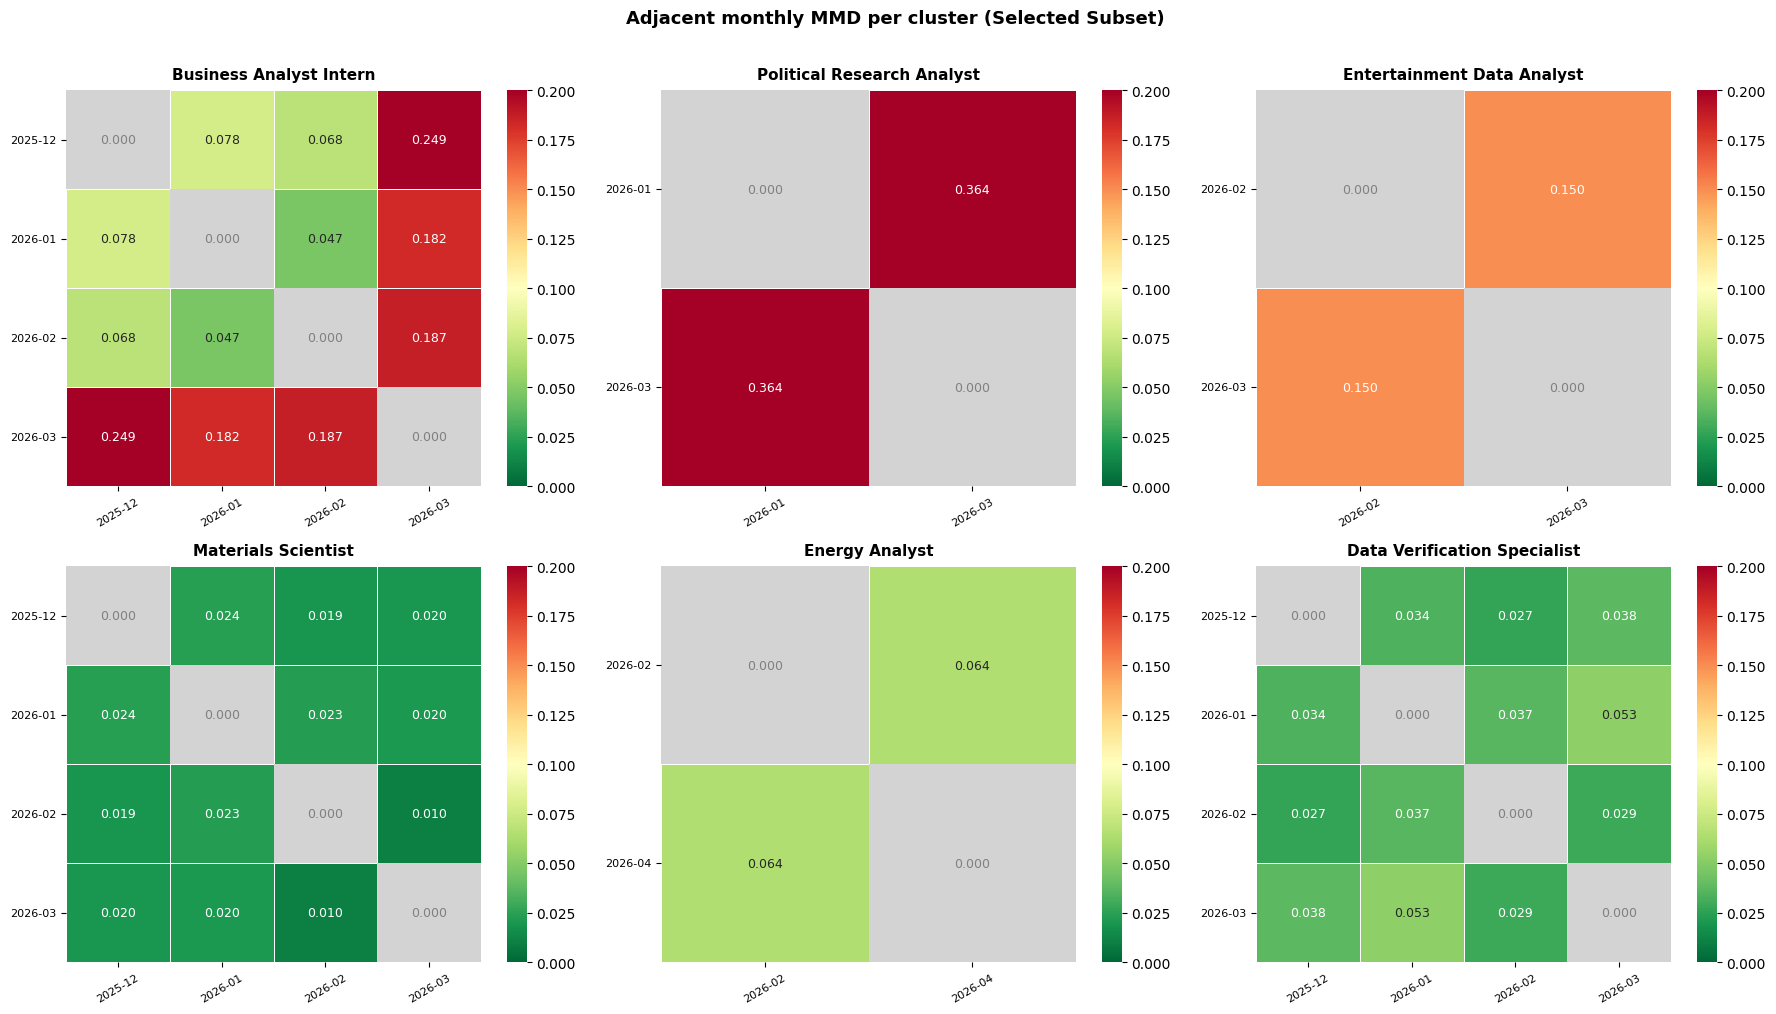

In [ ]:
# --- MINIMAL EDIT: Subset to 6 clusters ---
# We take the first 6 clusters from the sorted keys
subset_keys = sorted(pairwise_mmd.keys())[:6]
subset_mmd = {k: pairwise_mmd[k] for k in subset_keys}

# Updated grid logic based on subset
n_clusters = len(subset_mmd)
n_cols = 3
n_rows = (n_clusters + n_cols - 1) // n_cols

print(f"Plotting {n_clusters} clusters in a {n_rows} x {n_cols} grid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
axes = axes.flatten()

# Iterate over subset_mmd instead of the full pairwise_mmd
for ax_idx, (cluster_id, data) in enumerate(sorted(subset_mmd.items())):
    ax = axes[ax_idx]
    matrix = data['matrix']
    month_labels = data['months']
    cluster_name = data['cluster_name']

    mask = np.eye(len(month_labels), dtype=bool) | np.isnan(matrix)

    sns.heatmap(
        matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        xticklabels=month_labels,
        yticklabels=month_labels,
        ax=ax,
        mask=mask,
        vmin=0,
        vmax=0.2,
        linewidths=0.5,
        linecolor='white',
        cbar=True,
        annot_kws={'size': 9}
    )

    for i in range(len(month_labels)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                                    color='lightgray', lw=0))
        ax.text(i + 0.5, i + 0.5, '0.000', ha='center', va='center',
                fontsize=9, color='gray')

    ax.set_title(cluster_name, fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

# Hide any unused axes
for ax_idx in range(len(subset_mmd), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Adjacent monthly MMD per cluster (Selected Subset)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [ ]:
print("Eligible clusters:")
for cid, month_data in eligible.items():
    print(f"  Cluster {cid} ({cluster_names[cid]}): {sorted([str(m) for m in month_data.keys()])}")

Eligible clusters:
  Cluster 11 (Business Analyst Intern): ['2025-12', '2026-01', '2026-02', '2026-03']
  Cluster 13 (Political Research Analyst): ['2026-01', '2026-03']
  Cluster 14 (Entertainment Data Analyst): ['2026-02', '2026-03']
  Cluster 20 (Materials Scientist): ['2025-12', '2026-01', '2026-02', '2026-03']
  Cluster 23 (Energy Analyst): ['2026-02', '2026-04']
  Cluster 24 (Data Verification Specialist): ['2025-12', '2026-01', '2026-02', '2026-03']
  Cluster 28 (Biotechnology Intern): ['2026-01', '2026-02', '2026-03', '2026-04']
  Cluster 29 (Healthcare Internship): ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Cluster 30 (Resource Management Intern): ['2025-12', '2026-01', '2026-02']
  Cluster 31 (Hackathon Coordinator): ['2026-02', '2026-04']
  Cluster 32 (Software Development Intern): ['2026-01', '2026-02']
  Cluster 35 (Insurance Analyst): ['2026-01', '2026-04']
  Cluster 42 (Industrial Robotics Intern): ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  

## Interpretation guide
- **MMD = 0**: the cluster's embedding distribution is identical between two months — perfectly stable
- **Low MMD (< 0.01)**: minor fluctuation, cluster is broadly stable — the types of jobs in this segment did not change materially
- **Moderate MMD (0.01 – 0.05)**: noticeable shift — could indicate new tools or requirements entering the cluster's postings
- **High MMD (> 0.05)**: significant distributional shift — the cluster's character changed substantially between months, warranting manual inspection of what features changed
- clusters with consistently high MMD across all transitions are the most volatile market segments; clusters with near-zero MMD across all transitions are structurally stable
- note: MMD is scale-sensitive to the embedding space, so compare values *within this notebook* rather than against external benchmarks

# Narrative shift analysis for high-MMD clusters
- select the clusters with the greatest distributional shift (top N by max MMD)
- for each selected cluster, generate one LLM summary per monthly snapshot
- compare summaries across timestamps to see how the cluster's character changed

In [ ]:
import random
TOP_N_CLUSTERS = 3      # how many high-shift clusters to analyze
MIN_DOCS_PER_MONTH = 10 # minimum postings to generate a summary for a given month

# rank clusters by max MMD across any single transition
top_shifted = (
    cluster_stability
    .sort_values('max_mmd', ascending=False)
    .head(TOP_N_CLUSTERS)
)

print("Clusters selected for narrative shift analysis:")
print(top_shifted[['cluster_name', 'mean_mmd', 'max_mmd']].to_string(index=False))

months = sorted(df_filtered['month_bin'].dropna().unique())

def summarize_month_snapshot(docs, cluster_name, month):
    """summarize a cluster's job postings for a specific month"""
    sample = random.sample(docs, min(30, len(docs)))
    combined = "\n\n---\n\n".join(sample)
    prompt = f"""Below are job descriptions from the '{cluster_name}' cluster posted in {month}.

Write a concise 2-3 sentence summary describing:
1. The dominant role type and responsibilities
2. Key technical skills, tools, or qualifications emphasized
3. Any notable patterns or requirements

Be specific and factual — base your answer only on what appears in the descriptions below.

Job descriptions:
{combined[:6000]}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a job market analyst writing precise monthly snapshots of job cluster characteristics."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,  # low temp here — we want factual not creative
        max_tokens=200
    )
    return response.choices[0].message.content.strip()

# generate summaries per cluster per month
narrative_results = {}

for _, row in top_shifted.iterrows():
    cluster_id = int(row['cluster_id'])
    cluster_name = row['cluster_name']
    print(f"\nGenerating monthly snapshots for: {cluster_name}")

    monthly_summaries = {}
    for month in months:
        month_docs = df_filtered[
            (df_filtered['cluster'] == cluster_id) &
            (df_filtered['month_bin'] == month)
        ]['cleaned_description'].tolist()

        if len(month_docs) < MIN_DOCS_PER_MONTH:
            print(f"  {month}: only {len(month_docs)} docs, skipping.")
            continue

        print(f"  {month}: {len(month_docs)} docs")
        summary = summarize_month_snapshot(month_docs, cluster_name, str(month))
        monthly_summaries[str(month)] = {
            'summary': summary,
            'n_docs': len(month_docs)
        }

    narrative_results[cluster_id] = {
        'cluster_name': cluster_name,
        'monthly_summaries': monthly_summaries
    }

print("\nDone.")

Clusters selected for narrative shift analysis:
              cluster_name  mean_mmd  max_mmd
Political Research Analyst  0.363734 0.363734
      Biotechnology Intern  0.129835 0.233938
   Business Analyst Intern  0.103984 0.187025

Generating monthly snapshots for: Political Research Analyst
  2025-12: only 0 docs, skipping.
  2026-01: 15 docs
  2026-02: only 5 docs, skipping.
  2026-03: 13 docs
  2026-04: only 6 docs, skipping.
  2026-05: only 0 docs, skipping.

Generating monthly snapshots for: Biotechnology Intern
  2025-12: only 3 docs, skipping.
  2026-01: 13 docs
  2026-02: 37 docs
  2026-03: 12 docs
  2026-04: 22 docs
  2026-05: only 0 docs, skipping.

Generating monthly snapshots for: Business Analyst Intern
  2025-12: 14 docs
  2026-01: 13 docs
  2026-02: 26 docs
  2026-03: 30 docs
  2026-04: only 5 docs, skipping.
  2026-05: only 2 docs, skipping.

Done.


In [ ]:
for cluster_id, data in narrative_results.items():
    cluster_name = data['cluster_name']
    monthly = data['monthly_summaries']

    print(f"cluster: {cluster_name}")

    for month, info in sorted(monthly.items()):
        print(f"\n[{month}] — {info['n_docs']} postings")
        print(info['summary'])

    print()

cluster: Political Research Analyst

[2026-01] — 15 postings
The dominant role type in the Political Research Analyst cluster is that of an intern, focusing on data visualization and political research support. Key responsibilities include creating visual representations of data, conducting research on political candidates and initiatives, and summarizing findings for internal use. Emphasized technical skills include proficiency in data analysis tools such as Excel, R, and Python, as well as design software like Adobe Illustrator and Datawrapper, with a preference for candidates who have experience in data journalism or visual communication. Notable patterns in the requirements highlight the importance of organizational skills, attention to detail, and a commitment to diversity and inclusion within the political landscape.

[2026-03] — 13 postings
The dominant role type in the Political Research Analyst cluster is that of an intern, specifically aimed at graduate students, who are resp

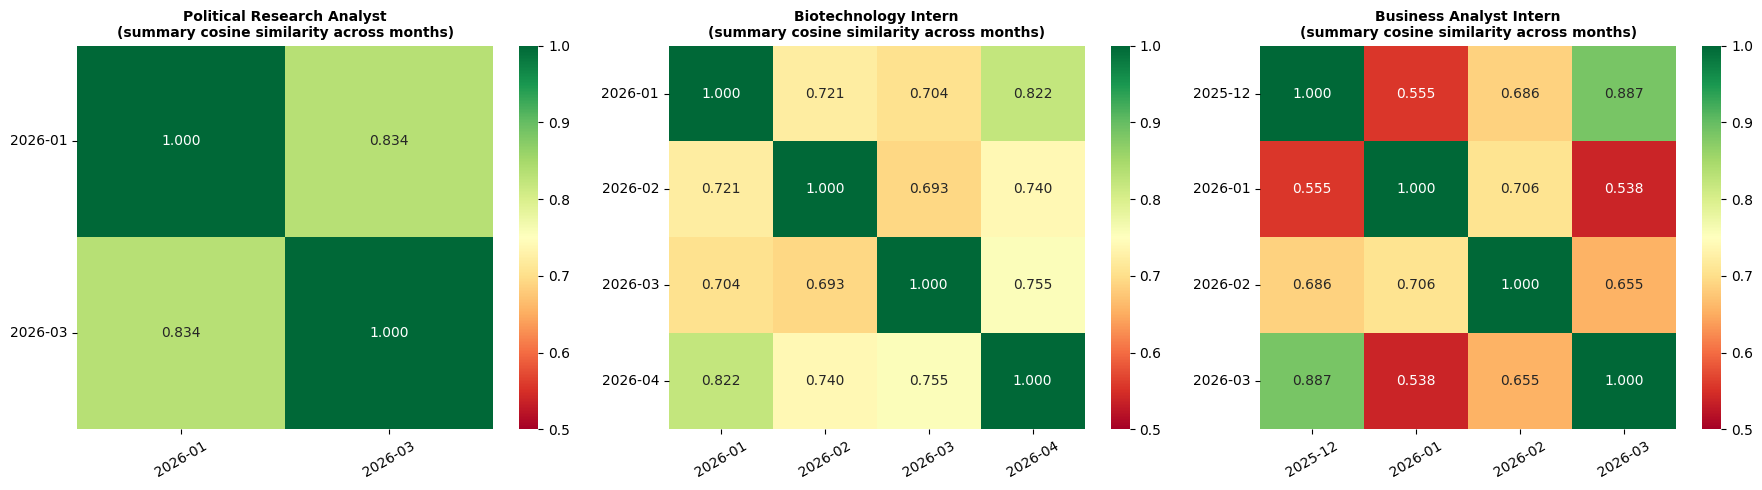

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

fig, axes = plt.subplots(1, len(narrative_results), figsize=(6 * len(narrative_results), 5))
if len(narrative_results) == 1:
    axes = [axes]

for ax, (cluster_id, data) in zip(axes, narrative_results.items()):
    cluster_name = data['cluster_name']
    monthly = data['monthly_summaries']

    if len(monthly) < 2:
        ax.set_title(f"{cluster_name}\n(insufficient months)")
        continue

    month_labels = sorted(monthly.keys())
    summaries = [monthly[m]['summary'] for m in month_labels]
    embs = model.encode(summaries, show_progress_bar=False)
    sim_matrix = cos_sim(embs)

    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0.5, vmax=1.0,
        xticklabels=month_labels,
        yticklabels=month_labels,
        ax=ax,
        cbar=True
    )
    ax.set_title(f"{cluster_name}\n(summary cosine similarity across months)", fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

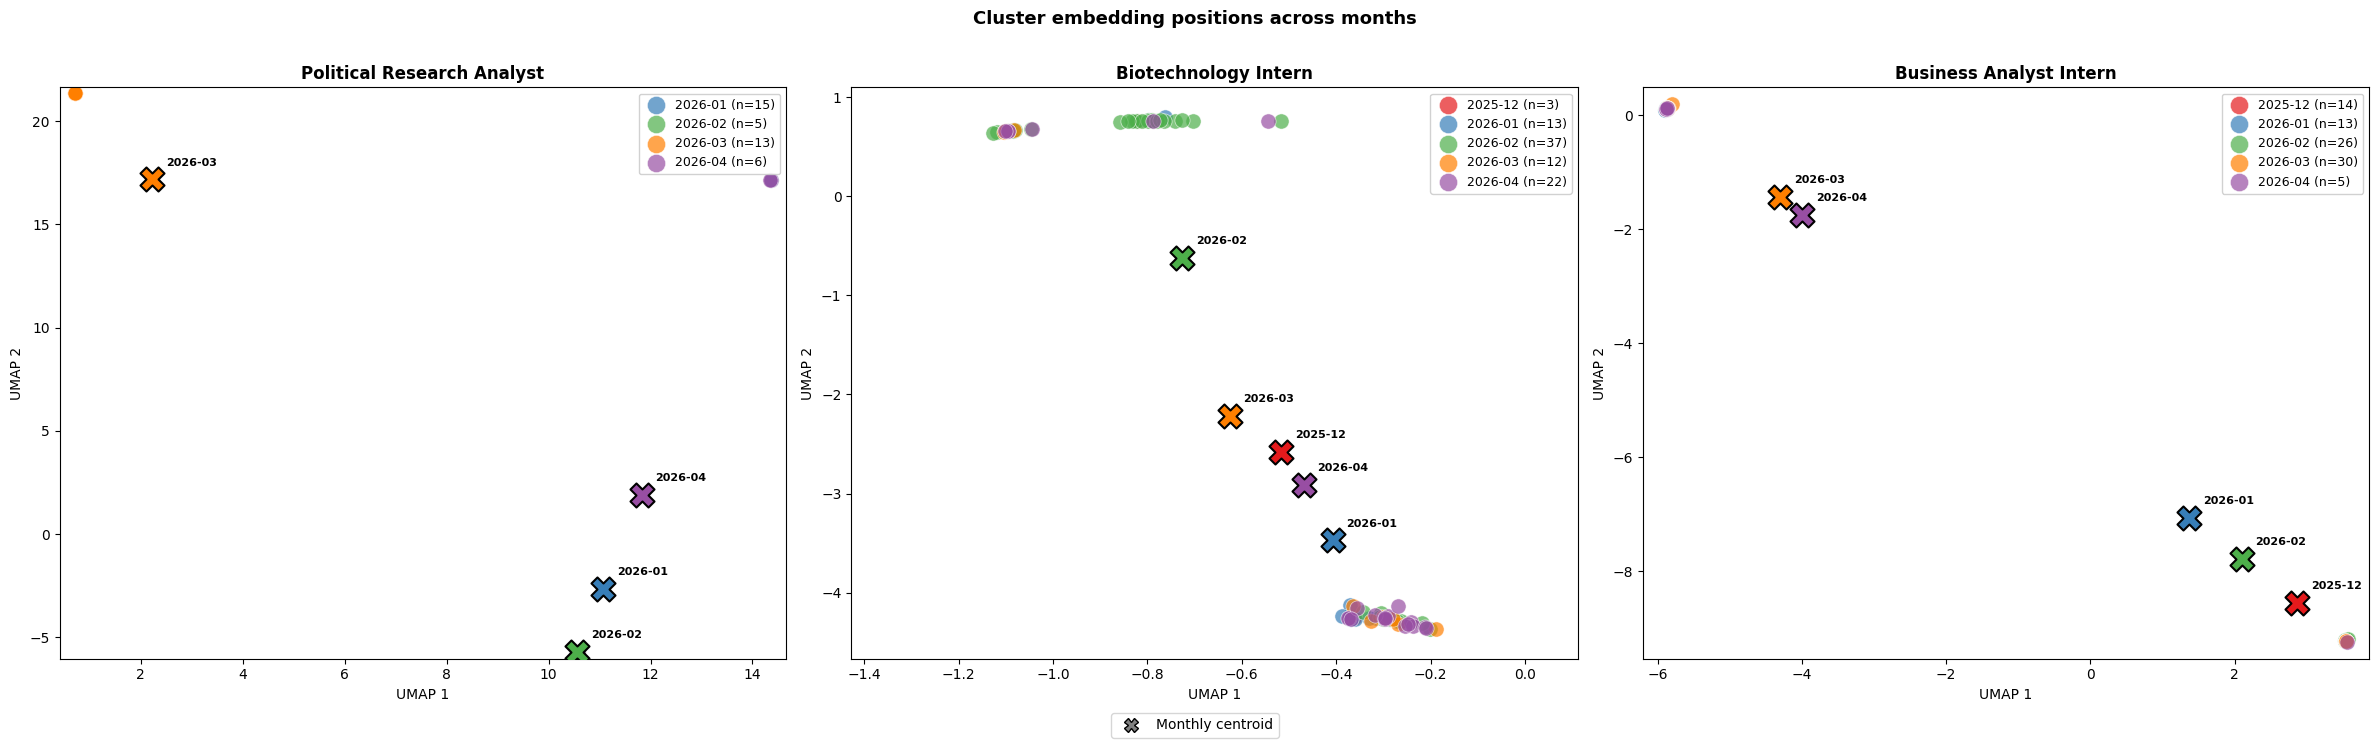

In [ ]:
from matplotlib.lines import Line2D

months = sorted(df_filtered['month_bin'].dropna().unique())
MONTH_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

n_clusters_plot = len(narrative_results)
fig, axes = plt.subplots(1, n_clusters_plot, figsize=(8 * n_clusters_plot, 7))
if n_clusters_plot == 1:
    axes = [axes]

for ax, (cluster_id, data) in zip(axes, narrative_results.items()):
    cluster_name = data['cluster_name']

    plotted_months = []
    for color, month in zip(MONTH_COLORS, months):
        month_mask = (
            (df_filtered['cluster'] == cluster_id) &
            (df_filtered['month_bin'] == month)
        )
        idxs = df_filtered[month_mask].index.values
        n = len(idxs)
        if n == 0:
            continue

        ax.scatter(
            embeddings_2d[idxs, 0],
            embeddings_2d[idxs, 1],
            s=120, alpha=0.7, color=color,
            edgecolors='white', linewidths=0.5,
            zorder=2, label=f"{month} (n={n})"
        )

        cx = embeddings_2d[idxs, 0].mean()
        cy = embeddings_2d[idxs, 1].mean()
        plotted_months.append((str(month), cx, cy, color, n))

    # draw centroids on top after all points, with offset labels
    for month_str, cx, cy, color, n in plotted_months:
        ax.scatter(cx, cy, s=300, color=color, marker='X',
                   edgecolors='black', linewidths=1.5, zorder=6)
        ax.annotate(
            month_str,
            xy=(cx, cy),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=8, color='black', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'),
            zorder=7
        )

    # zoom to cluster bounding box
    cluster_idxs = df_filtered[df_filtered['cluster'] == cluster_id].index.values
    if len(cluster_idxs) > 0:
        x_vals = embeddings_2d[cluster_idxs, 0]
        y_vals = embeddings_2d[cluster_idxs, 1]
        pad = 0.3
        ax.set_xlim(x_vals.min() - pad, x_vals.max() + pad)
        ax.set_ylim(y_vals.min() - pad, y_vals.max() + pad)

    ax.set_title(cluster_name, fontsize=12, fontweight='bold')
    ax.set_xlabel("UMAP 1", fontsize=10)
    ax.set_ylabel("UMAP 2", fontsize=10)
    ax.legend(fontsize=9, loc='upper right', framealpha=0.9,
              markerscale=1.2, handletextpad=0.5)

legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=10, label='Monthly centroid')
]
fig.legend(handles=legend_elements, loc='lower center', fontsize=10,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Cluster embedding positions across months",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Bootstrap Narrative Coherence Analysis
- randomly sample subsets of job descriptions from each cluster and generate independent LLM summaries
- measure how consistent those summaries are across samples using embedding cosine similarity
- high coherence → cluster is tight and internally homogeneous
- low coherence → cluster contains mixed job functions and may need splitting
- complements MMD (which measures distributional shift over time) by measuring internal narrative consistency at a point in time

In [ ]:
import random
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

N_BOOTSTRAP = 10      # number of random samples per cluster
SAMPLE_SIZE = 20 # job descriptions per sample
GPT_TEMPERATURE = 0.7 # non-zero so summaries vary across calls

def summarize_sample(docs, cluster_name):
    """call GPT on a random sample of job descriptions and return a summary string"""
    combined = "\n\n---\n\n".join(docs)
    prompt = f"""Below are {len(docs)} job descriptions from a cluster currently labeled '{cluster_name}'.

Write a concise 2-3 sentence summary describing:
1. What kind of role this cluster represents
2. The key technical skills or tools that appear
3. The industry or business function these roles serve

Be specific — avoid generic phrases like 'data-related roles'.

Job descriptions:
{combined[:6000]}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a job market analyst who writes precise, specific cluster summaries."},
            {"role": "user", "content": prompt}
        ],
        temperature=GPT_TEMPERATURE,
        max_tokens=200
    )
    return response.choices[0].message.content.strip()

# run bootstrap per cluster
bootstrap_results = {}

named_clusters = {cid: name for cid, name in cluster_names.items()}

for cluster_id, cluster_name in sorted(named_clusters.items()):
    cluster_docs = df_filtered[df_filtered['cluster'] == cluster_id]['cleaned_description'].tolist()

    if len(cluster_docs) < SAMPLE_SIZE:
        print(f"Cluster {cluster_id} ({cluster_name}): only {len(cluster_docs)} docs, skipping.")
        continue

    print(f"Cluster {cluster_id} ({cluster_name}): generating {N_BOOTSTRAP} summaries...")
    summaries = []
    for i in range(N_BOOTSTRAP):
        sample = random.sample(cluster_docs, SAMPLE_SIZE)
        summary = summarize_sample(sample, cluster_name)
        summaries.append(summary)

    bootstrap_results[cluster_id] = {
        'cluster_name': cluster_name,
        'summaries': summaries
    }

print(f"\nDone. Bootstrap summaries generated for {len(bootstrap_results)} clusters.")

Cluster 0 (Casino Operations Intern): generating 10 summaries...
Cluster 1 (Polymer Science Intern): generating 10 summaries...
Cluster 2 (Data Engineering Intern): generating 10 summaries...
Cluster 3 (Quantitative Research Intern): generating 10 summaries...
Cluster 4 (Financial Technology Analyst): generating 10 summaries...
Cluster 5 (AI Visualization Engineer): generating 10 summaries...
Cluster 6 (Business Intelligence Analyst): generating 10 summaries...
Cluster 7 (Supply Chain Analyst): generating 10 summaries...
Cluster 8 (3D Modeling Analyst): generating 10 summaries...
Cluster 9 (Machine Learning Intern): generating 10 summaries...
Cluster 10 (Manufacturing Data Analyst): generating 10 summaries...
Cluster 11 (Business Analyst Intern): generating 10 summaries...
Cluster 12 (Data Migration Specialist): generating 10 summaries...
Cluster 13 (Political Research Analyst): generating 10 summaries...
Cluster 14 (Entertainment Data Analyst): generating 10 summaries...
Cluster 15 (A

In [ ]:
# embed all summaries and compute mean pairwise cosine similarity per cluster
# this is the narrative coherence score: 1.0 = identical summaries, 0.0 = completely unrelated

coherence_records = []

for cluster_id, data in bootstrap_results.items():
    summaries = data['summaries']
    summary_embeddings = model.encode(summaries, show_progress_bar=False)

    sim_matrix = cos_sim(summary_embeddings)
    np.fill_diagonal(sim_matrix, 0)  # exclude self-similarity

    # mean of off-diagonal elements
    n = len(summaries)
    mean_coherence = sim_matrix.sum() / (n * (n - 1))

    coherence_records.append({
        'cluster_id':   cluster_id,
        'cluster_name': data['cluster_name'],
        'coherence':    round(mean_coherence, 4),
        'n_summaries':  n
    })

coherence_df = pd.DataFrame(coherence_records).sort_values('coherence', ascending=False)

print("Narrative coherence scores per cluster (higher = more internally consistent):")
print(coherence_df.to_string(index=False))

print(f"\n--- Most coherent clusters (top 5) ---")
print(coherence_df.head(5)[['cluster_name', 'coherence']].to_string(index=False))

print(f"\n--- Least coherent clusters (bottom 5) ---")
print(coherence_df.tail(5)[['cluster_name', 'coherence']].to_string(index=False))

Narrative coherence scores per cluster (higher = more internally consistent):
 cluster_id                     cluster_name  coherence  n_summaries
         27            Mortgage Data Analyst     0.9647           10
         39 Business Intelligence Consultant     0.9520           10
         26          Data Integration Intern     0.9470           10
          5        AI Visualization Engineer     0.9455           10
         34           Data Pipeline Engineer     0.9446           10
          1           Polymer Science Intern     0.9438           10
          4     Financial Technology Analyst     0.9389           10
         18        Supply Chain Data Analyst     0.9351           10
         25        Business Analytics Intern     0.9347           10
         38           Social Network Analyst     0.9339           10
         35                Insurance Analyst     0.9319           10
         40            ETL Consultant Intern     0.9316           10
          7             S

/tmp/ipykernel_14164/1706189776.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




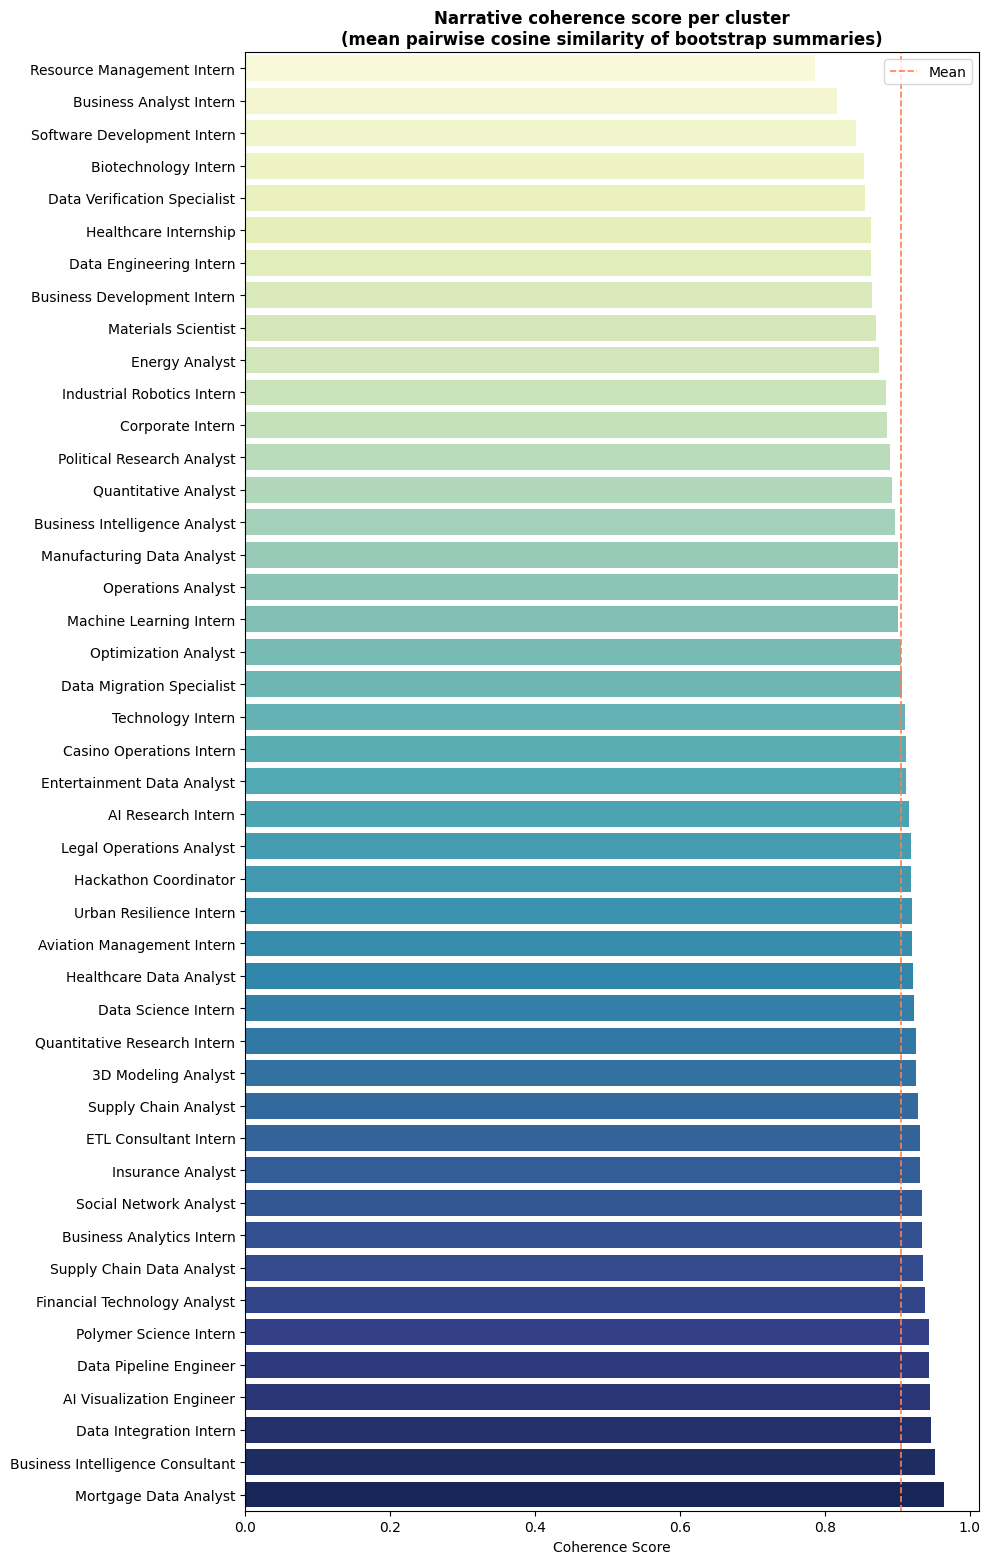

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, max(4, len(coherence_df) * 0.35)))
sns.barplot(
    data=coherence_df.sort_values('coherence'),
    x='coherence',
    y='cluster_name',
    palette='YlGnBu',
    ax=ax
)
ax.set_title("Narrative coherence score per cluster\n(mean pairwise cosine similarity of bootstrap summaries)", fontsize=12, fontweight='bold')
ax.set_xlabel("Coherence Score")
ax.set_ylabel("")
ax.axvline(x=coherence_df['coherence'].mean(), color='coral', linewidth=1.2, linestyle='--', label='Mean')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()